# Import Library

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, hamming_loss, classification_report,
                             confusion_matrix)
from sklearn.preprocessing import MultiLabelBinarizer
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
print("="*80)
print("LOAD DATA HASIL LABELING")
print("="*80 + "\n")

# Path dataset
path_lda = "/content/drive/MyDrive/SKRIPSI/DATASET/ulasan_plnmobile_labeling_LDA_final.csv"
path_ber = "/content/drive/MyDrive/SKRIPSI/DATASET/ulasan_plnmobile_labeling_BERTopic_final.csv"

# Load dataset
df_lda = pd.read_csv(
    path_lda,
    sep=';',
    encoding='utf-8',
    engine='python'
)

df_bertopic = pd.read_csv(
    path_ber,
    sep=';',
    encoding='utf-8',
    engine='python'
)


print("Dataset LDA:")
print(f"  Total ulasan: {len(df_lda):,}")
print(f"  Kolom aspek: User Experience, Service Quality")
print(f"  Shape: {df_lda.shape}")

print("\nDataset BERTopic:")
print(f"  Total ulasan: {len(df_bertopic):,}")
print(f"  Kolom aspek: User Experience, Service Quality, System Reliability")
print(f"  Shape: {df_bertopic.shape}")

# Tampilkan sample data
print("\n" + "-"*80)
print("Sample Data LDA (5 baris pertama):")
print("-"*80)
print(df_lda.head())

print("\n" + "-"*80)
print("Sample Data BERTopic (5 baris pertama):")
print("-"*80)
print(df_bertopic.head())

LOAD DATA HASIL LABELING

Dataset LDA:
  Total ulasan: 16,220
  Kolom aspek: User Experience, Service Quality
  Shape: (16220, 5)

Dataset BERTopic:
  Total ulasan: 16,220
  Kolom aspek: User Experience, Service Quality, System Reliability
  Shape: (16220, 6)

--------------------------------------------------------------------------------
Sample Data LDA (5 baris pertama):
--------------------------------------------------------------------------------
   id                                             ulasan  \
0   1  aplikasi yg sangat bermanfaat utk urusan kelis...   
1   2                   sangat membantu proses pengaduan   
2   3                      Lebih mudah dan cepat tanggap   
3   4  hadirnya aplikasi ini sangat guna ketika ada g...   
4   5  laporan langsung ke pln pakai pln mobile..muda...   

                                          final_text  User Experience  \
0                      aplikasi manfaat urus listrik                1   
1                                  

# Pembagian Data Modeling dan Data Validasi (90:10)

In [ ]:
print("PEMBAGIAN DATA (90% MODELING, 10% VALIDATION)")


# Set random seed untuk reproducibility
RANDOM_SEED = 42

# Fungsi pembagian data
def split_modeling_validation(df, test_size=0.1, random_state=42):
    """
    Membagi data menjadi 90% untuk modeling dan 10% untuk validation
    """
    # Gunakan stratify pada kolom pertama aspek untuk distribusi seimbang
    first_aspect_col = [col for col in df.columns if col not in ['id', 'ulasan', 'final_text']][0]

    df_modeling, df_validation = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=df[first_aspect_col]
    )

    return df_modeling.reset_index(drop=True), df_validation.reset_index(drop=True)

# Split dataset LDA
df_lda_modeling, df_lda_validation = split_modeling_validation(df_lda, test_size=0.1, random_state=RANDOM_SEED)

print("Dataset LDA:")
print(f"  Data Modeling (90%): {len(df_lda_modeling):,} ulasan")
print(f"  Data Validation (10%): {len(df_lda_validation):,} ulasan")

# Split dataset BERTopic
df_bertopic_modeling, df_bertopic_validation = split_modeling_validation(df_bertopic, test_size=0.1, random_state=RANDOM_SEED)

print("\nDataset BERTopic:")
print(f"  Data Modeling (90%): {len(df_bertopic_modeling):,} ulasan")
print(f"  Data Validation (10%): {len(df_bertopic_validation):,} ulasan")

# Simpan data validation untuk tahap akhir
df_lda_validation.to_csv('/content/lda_validation_data.csv', index=False)
df_bertopic_validation.to_csv('/content/bertopic_validation_data.csv', index=False)
print("\n✅ Data validation disimpan untuk evaluasi sistem tahap akhir")

PEMBAGIAN DATA (90% MODELING, 10% VALIDATION)
Dataset LDA:
  Data Modeling (90%): 14,598 ulasan
  Data Validation (10%): 1,622 ulasan

Dataset BERTopic:
  Data Modeling (90%): 14,598 ulasan
  Data Validation (10%): 1,622 ulasan

✅ Data validation disimpan untuk evaluasi sistem tahap akhir


# Persiapan Data untuk Klasifikasi Multi Label

In [ ]:
print("\n" + "="*80)
print("PERSIAPAN DATA UNTUK KLASIFIKASI MULTI-LABEL")
print("="*80 + "\n")

def prepare_multilabel_data(df, aspect_columns):
    """
    Menyiapkan data untuk klasifikasi multi-label
    Menggabungkan aspek dan sentimen menjadi label gabungan

    Contoh: User_Experience=1, Service_Quality=2 → ['UX_positive', 'SQ_negative']
    """
    X = df['final_text'].values

    # Buat label multi-label
    y_multilabel = []

    for idx, row in df.iterrows():
        labels = []
        for aspect in aspect_columns:
            sentiment_value = row[aspect]

            # Mapping sentimen
            if sentiment_value == 1:
                labels.append(f"{aspect}_positive")
            elif sentiment_value == 2:
                labels.append(f"{aspect}_negative")
            # Jika 0, tidak ada label untuk aspek tersebut

        y_multilabel.append(labels)

    return X, y_multilabel

# Definisi kolom aspek
lda_aspects = ['User Experience', 'Service Quality']
bertopic_aspects = ['User Experience', 'Service Quality', 'System Reliability']

# Prepare data LDA
X_lda, y_lda = prepare_multilabel_data(df_lda_modeling, lda_aspects)
print("Data LDA Modeling:")
print(f"  Jumlah dokumen (X): {len(X_lda):,}")
print(f"  Contoh label: {y_lda[:3]}")

# Prepare data BERTopic
X_bertopic, y_bertopic = prepare_multilabel_data(df_bertopic_modeling, bertopic_aspects)
print("\nData BERTopic Modeling:")
print(f"  Jumlah dokumen (X): {len(X_bertopic):,}")
print(f"  Contoh label: {y_bertopic[:3]}")

# Encode label multi-label ke binary matrix
mlb_lda = MultiLabelBinarizer()
y_lda_binary = mlb_lda.fit_transform(y_lda)

mlb_bertopic = MultiLabelBinarizer()
y_bertopic_binary = mlb_bertopic.fit_transform(y_bertopic)

print("\n" + "-"*80)
print("Label Classes:")
print("-"*80)
print(f"LDA Classes: {mlb_lda.classes_}")
print(f"BERTopic Classes: {mlb_bertopic.classes_}")


PERSIAPAN DATA UNTUK KLASIFIKASI MULTI-LABEL

Data LDA Modeling:
  Jumlah dokumen (X): 14,598
  Contoh label: [['User Experience_positive'], ['Service Quality_positive'], ['User Experience_positive']]

Data BERTopic Modeling:
  Jumlah dokumen (X): 14,598
  Contoh label: [['User Experience_positive'], ['Service Quality_positive'], ['User Experience_positive']]

--------------------------------------------------------------------------------
Label Classes:
--------------------------------------------------------------------------------
LDA Classes: ['Service Quality_negative' 'Service Quality_positive'
 'User Experience_negative' 'User Experience_positive']
BERTopic Classes: ['Service Quality_negative' 'Service Quality_positive'
 'System Reliability_negative' 'System Reliability_positive'
 'User Experience_negative' 'User Experience_positive']


# Definisi Skenario Pengujian

In [ ]:
print("DEFINISI SKENARIO PENGUJIAN")

scenarios = {
    'Skenario 1': {
        'topic_model': 'LDA',
        'classifier': 'SVM',
        'split_ratio': '90:10',
        'test_size': 0.1,
        'description': 'LDA + SVM dengan pembagian data 90:10'
    },
    'Skenario 2': {
        'topic_model': 'LDA',
        'classifier': 'Random Forest',
        'split_ratio': '90:10',
        'test_size': 0.1,
        'description': 'LDA + Random Forest dengan pembagian data 90:10'
    },
    'Skenario 3': {
        'topic_model': 'BERTopic',
        'classifier': 'SVM',
        'split_ratio': '90:10',
        'test_size': 0.1,
        'description': 'BERTopic + SVM dengan pembagian data 90:10'
    },
    'Skenario 4': {
        'topic_model': 'BERTopic',
        'classifier': 'Random Forest',
        'split_ratio': '90:10',
        'test_size': 0.1,
        'description': 'BERTopic + Random Forest dengan pembagian data 90:10'
    },
    'Skenario 5': {
        'topic_model': 'LDA',
        'classifier': 'SVM',
        'split_ratio': '80:20',
        'test_size': 0.2,
        'description': 'LDA + SVM dengan pembagian data 80:20'
    },
    'Skenario 6': {
        'topic_model': 'LDA',
        'classifier': 'Random Forest',
        'split_ratio': '80:20',
        'test_size': 0.2,
        'description': 'LDA + Random Forest dengan pembagian data 80:20'
    },
    'Skenario 7': {
        'topic_model': 'BERTopic',
        'classifier': 'SVM',
        'split_ratio': '80:20',
        'test_size': 0.2,
        'description': 'BERTopic + SVM dengan pembagian data 80:20'
    },
    'Skenario 8': {
        'topic_model': 'BERTopic',
        'classifier': 'Random Forest',
        'split_ratio': '80:20',
        'test_size': 0.2,
        'description': 'BERTopic + Random Forest dengan pembagian data 80:20'
    }
}

# Tampilkan tabel skenario
print("Tabel Skenario Pengujian:")
print("-"*80)
print(f"{'Skenario':<12} {'Topic Model':<12} {'Classifier':<18} {'Split Ratio':<12} {'Deskripsi':<30}")
print("-"*80)
for scenario_name, config in scenarios.items():
    print(f"{scenario_name:<12} {config['topic_model']:<12} {config['classifier']:<18} "
          f"{config['split_ratio']:<12} {config['description']:<30}")
print("-"*80)

DEFINISI SKENARIO PENGUJIAN
Tabel Skenario Pengujian:
--------------------------------------------------------------------------------
Skenario     Topic Model  Classifier         Split Ratio  Deskripsi                     
--------------------------------------------------------------------------------
Skenario 1   LDA          SVM                90:10        LDA + SVM dengan pembagian data 90:10
Skenario 2   LDA          Random Forest      90:10        LDA + Random Forest dengan pembagian data 90:10
Skenario 3   BERTopic     SVM                90:10        BERTopic + SVM dengan pembagian data 90:10
Skenario 4   BERTopic     Random Forest      90:10        BERTopic + Random Forest dengan pembagian data 90:10
Skenario 5   LDA          SVM                80:20        LDA + SVM dengan pembagian data 80:20
Skenario 6   LDA          Random Forest      80:20        LDA + Random Forest dengan pembagian data 80:20
Skenario 7   BERTopic     SVM                80:20        BERTopic + SVM dengan

# Fungsi Helper untuk Training dan Evaluasi

In [ ]:
print("PERSIAPAN FUNGSI TRAINING DAN EVALUASI")

def create_tfidf_vectorizer():
    """
    Membuat TF-IDF Vectorizer
    """
    vectorizer = TfidfVectorizer(
        max_features=5000,  # Maksimal 5000 fitur
        ngram_range=(1, 2),  # Unigram dan bigram
        min_df=2,  # Kata minimal muncul di 2 dokumen
        max_df=0.95  # Kata maksimal muncul di 95% dokumen
    )
    return vectorizer

def get_classifier(classifier_name):
    """
    Mendapatkan classifier dengan hyperparameter terbaik
    """
    if classifier_name == 'SVM':
        # Grid search parameters untuk SVM
        param_grid = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
        base_model = SVC(random_state=RANDOM_SEED, probability=True)

    elif classifier_name == 'Random Forest':
        # Grid search parameters untuk Random Forest
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
        base_model = RandomForestClassifier(random_state=RANDOM_SEED)

    return base_model, param_grid

print("PERSIAPAN FUNGSI TRAINING DAN EVALUASI")

def create_tfidf_vectorizer():
    """
    Membuat TF-IDF Vectorizer
    """
    vectorizer = TfidfVectorizer(
        max_features=5000,  # Maksimal 5000 fitur
        ngram_range=(1, 2),  # Unigram dan bigram
        min_df=2,  # Kata minimal muncul di 2 dokumen
        max_df=0.95  # Kata maksimal muncul di 95% dokumen
    )
    return vectorizer

def get_classifier(classifier_name):
    """
    Mendapatkan classifier dengan hyperparameter terbaik
    """
    if classifier_name == 'SVM':
        # Grid search parameters untuk SVM
        param_grid = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
        base_model = SVC(random_state=RANDOM_SEED, probability=True)

    elif classifier_name == 'Random Forest':
        # Grid search parameters untuk Random Forest
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }
        base_model = RandomForestClassifier(random_state=RANDOM_SEED)

    return base_model, param_grid

def train_and_evaluate_model(X_train, X_test, y_train, y_test, classifier_name, mlb, scenario_name=""):
    """
    Training dan evaluasi model dengan Grid Search + Confusion Matrix Visualization

    TAMBAHAN BARU:
    - Parameter scenario_name untuk penamaan folder CM
    - Prediksi train set untuk cek overfitting
    - Generate & simpan confusion matrix per label
    - Return train_metrics
    """
    import os
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt

    print(f"\n{'='*80}")
    print(f"Training model: {classifier_name}")
    print(f"{'='*80}")

    # TF-IDF Vectorization
    print("  Proses TF-IDF Vectorization...")
    vectorizer = create_tfidf_vectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    print(f"    ✓ Shape X_train: {X_train_tfidf.shape}")
    print(f"    ✓ Shape X_test: {X_test_tfidf.shape}")

    # Get classifier dan parameter grid
    base_model, param_grid = get_classifier(classifier_name)

    # Grid Search dengan Cross Validation
    print(f"\n  Proses Grid Search CV untuk hyperparameter tuning...")
    grid_search = GridSearchCV(
        base_model,
        param_grid,
        cv=5,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )

    # Training per label
    print(f"\n  Training model untuk {y_train.shape[1]} label...")

    models = []
    best_params_list = []
    confusion_matrices = []

    for i in range(y_train.shape[1]):
        print(f"    Training label {i+1}/{y_train.shape[1]}: {mlb.classes_[i]}", end=" ")
        grid_search.fit(X_train_tfidf, y_train[:, i])
        models.append(grid_search.best_estimator_)
        best_params_list.append(grid_search.best_params_)
        print("✓")

    print(f"\n  ✅ Training selesai!")

    # ── PREDIKSI TEST ──────────────────────────────────────────────
    print(f"\n  Proses prediksi pada data test...")
    y_pred = np.zeros_like(y_test)
    for i, model in enumerate(models):
        y_pred[:, i] = model.predict(X_test_tfidf)
    print(f"    ✓ Prediksi test selesai")

    # ── PREDIKSI TRAIN (untuk overfitting check) ───────────────────
    print(f"  Proses prediksi pada data train...")
    y_pred_train = np.zeros_like(y_train)
    for i, model in enumerate(models):
        y_pred_train[:, i] = model.predict(X_train_tfidf)
    print(f"    ✓ Prediksi train selesai")

    # ── EVALUASI TEST ──────────────────────────────────────────────
    print(f"\n  {'='*60}")
    print(f"  HASIL EVALUASI MODEL (TEST SET)")
    print(f"  {'='*60}")

    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='macro', zero_division=0)
    h_loss    = hamming_loss(y_test, y_pred)

    print(f"  Accuracy         : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision (Macro): {precision:.4f}")
    print(f"  Recall (Macro)   : {recall:.4f}")
    print(f"  F1-Score (Macro) : {f1:.4f}")
    print(f"  Hamming Loss     : {h_loss:.4f}")

    # ── EVALUASI TRAIN (untuk overfitting) ─────────────────────────
    train_accuracy  = accuracy_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train, average='macro', zero_division=0)
    train_recall    = recall_score(y_train, y_pred_train, average='macro', zero_division=0)
    train_f1        = f1_score(y_train, y_pred_train, average='macro', zero_division=0)
    train_h_loss    = hamming_loss(y_train, y_pred_train)

    # ── PER-LABEL METRICS & CONFUSION MATRIX ───────────────────────
    print(f"\n  {'='*60}")
    print(f"  METRIK PER LABEL & CONFUSION MATRIX")
    print(f"  {'='*60}")

    per_label_metrics = []

    # Create directory untuk confusion matrices
    safe_scenario = scenario_name.replace(" ", "_").replace(":", "")
    cm_dir = f'/content/confusion_matrices/{safe_scenario}'
    os.makedirs(cm_dir, exist_ok=True)

    # Hitung ukuran subplot
    n_labels = len(mlb.classes_)
    n_cols = 2
    n_rows = (n_labels + 1) // n_cols

    # Create figure untuk semua CM
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
    axes = axes.flatten() if n_labels > 1 else [axes]

    for i, label_name in enumerate(mlb.classes_):
        # Metrik per label
        acc  = accuracy_score(y_test[:, i], y_pred[:, i])
        prec = precision_score(y_test[:, i], y_pred[:, i], zero_division=0)
        rec  = recall_score(y_test[:, i], y_pred[:, i], zero_division=0)
        f1l  = f1_score(y_test[:, i], y_pred[:, i], zero_division=0)

        print(f"\n  Label: {label_name}")
        print(f"    Accuracy : {acc:.4f}")
        print(f"    Precision: {prec:.4f}")
        print(f"    Recall   : {rec:.4f}")
        print(f"    F1-Score : {f1l:.4f}")

        per_label_metrics.append({
            'label': label_name,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1_score': f1l
        })

        # Confusion matrix
        cm = confusion_matrix(y_test[:, i], y_pred[:, i])

        # Plot CM dengan ConfusionMatrixDisplay
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=['Tidak Ada (0)', 'Ada (1)']
        )
        disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
        axes[i].set_title(f'{label_name}', fontsize=10, fontweight='bold')
        axes[i].set_xlabel('Prediksi', fontsize=9)
        axes[i].set_ylabel('Aktual', fontsize=9)

    # Sembunyikan subplot kosong
    for j in range(n_labels, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f'Confusion Matrix — {scenario_name}\n{classifier_name}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()

    cm_file = f'{cm_dir}/all_labels_cm.png'
    plt.savefig(cm_file, dpi=200, bbox_inches='tight')
    plt.close()

    print(f"\n  ✅ Confusion matrices disimpan di {cm_dir}/")

    # ── RETURN RESULTS ─────────────────────────────────────────────
    results = {
        'vectorizer': vectorizer,
        'models': models,
        'best_params': best_params_list,
        'metrics': {
            'accuracy': accuracy,
            'precision_macro': precision,
            'recall_macro': recall,
            'f1_macro': f1,
            'hamming_loss': h_loss
        },
        'train_metrics': {
            'accuracy': train_accuracy,
            'precision_macro': train_precision,
            'recall_macro': train_recall,
            'f1_macro': train_f1,
            'hamming_loss': train_h_loss
        },
        'per_label_metrics': per_label_metrics,
        'y_test': y_test,
        'y_pred': y_pred,
        'y_train': y_train,
        'y_pred_train': y_pred_train,
        'confusion_matrix_path': cm_dir
    }

    return results

PERSIAPAN FUNGSI TRAINING DAN EVALUASI
PERSIAPAN FUNGSI TRAINING DAN EVALUASI


# Eksekusi Semua Skenario Pengujian

In [ ]:
print("EKSEKUSI 8 SKENARIO PENGUJIAN")

# Dictionary untuk menyimpan hasil semua skenario
all_results = {}

for scenario_name, config in scenarios.items():
    print("\n" + "#"*80)
    print(f"# {scenario_name}: {config['description']}")
    print("#"*80)

    # Pilih dataset berdasarkan topic model
    if config['topic_model'] == 'LDA':
        X = X_lda
        y = y_lda_binary
        mlb = mlb_lda
    else:  # BERTopic
        X = X_bertopic
        y = y_bertopic_binary
        mlb = mlb_bertopic

    # Split data train-test berdasarkan rasio
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=config['test_size'],
        random_state=RANDOM_SEED,
        stratify=y[:, 0]  # Stratify pada label pertama
    )

    print(f"\nPembagian Data {config['split_ratio']}:")
    print(f"  Training: {len(X_train):,} samples ({(1-config['test_size'])*100:.0f}%)")
    print(f"  Testing : {len(X_test):,} samples ({config['test_size']*100:.0f}%)")

    # ✅ Training dan evaluasi
    results = train_and_evaluate_model(
        X_train, X_test, y_train, y_test,
        config['classifier'],
        mlb,
        scenario_name
    )

    # ✅ Simpan hasil
    all_results[scenario_name] = {
        'config': config,
        'results': results,
        'data_split': {
            'train_size': len(X_train),
            'test_size': len(X_test)
        }
    }

    print(f"\n✅ {scenario_name} selesai!")

print("\n" + "="*80)
print("✅ SEMUA SKENARIO PENGUJIAN SELESAI!")
print("="*80)

EKSEKUSI 8 SKENARIO PENGUJIAN

################################################################################
# Skenario 1: LDA + SVM dengan pembagian data 90:10
################################################################################

Pembagian Data 90:10:
  Training: 13,138 samples (90%)
  Testing : 1,460 samples (10%)

Training model: SVM
  Proses TF-IDF Vectorization...
    ✓ Shape X_train: (13138, 5000)
    ✓ Shape X_test: (1460, 5000)

  Proses Grid Search CV untuk hyperparameter tuning...

  Training model untuk 4 label...
    Training label 1/4: Service Quality_negative ✓
    Training label 2/4: Service Quality_positive ✓
    Training label 3/4: User Experience_negative ✓
    Training label 4/4: User Experience_positive ✓

  ✅ Training selesai!

  Proses prediksi pada data test...
    ✓ Prediksi test selesai
  Proses prediksi pada data train...
    ✓ Prediksi train selesai

  HASIL EVALUASI MODEL (TEST SET)
  Accuracy         : 0.8000 (80.00%)
  Precision (Macro): 0.7

# EXPORT HASIL PREDIKSI PER SKENARIO KE CSV

In [ ]:
import pandas as pd
import os

print("\n" + "="*80)
print("EXPORT HASIL PREDIKSI PER SKENARIO")
print("="*80)

output_dir = "/content/prediction_results_per_skenario"
os.makedirs(output_dir, exist_ok=True)

for scenario_name, scenario_data in all_results.items():

    print(f"\nMemproses {scenario_name}...")

    results = scenario_data['results']
    config = scenario_data['config']

    y_test = results['y_test']
    y_pred = results['y_pred']

    # Ambil kembali X_test sesuai topic model
    if config['topic_model'] == 'LDA':
        X = X_lda
        y = y_lda_binary
        mlb = mlb_lda
    else:
        X = X_bertopic
        y = y_bertopic_binary
        mlb = mlb_bertopic

    # Split ulang agar urutan sama
    X_train, X_test, y_train, y_test_split = train_test_split(
        X, y,
        test_size=config['test_size'],
        random_state=RANDOM_SEED,
        stratify=y[:, 0]
    )

    # Decode true & predicted labels
    y_true_labels = mlb.inverse_transform(y_test)
    y_pred_labels = mlb.inverse_transform(y_pred)

    # Format ke list string
    y_true_formatted = [list(labels) for labels in y_true_labels]
    y_pred_formatted = [list(labels) for labels in y_pred_labels]

    # Buat DataFrame
    df_predictions = pd.DataFrame({
        'ulasan': X_test,
        'y_true': y_true_formatted,
        'y_pred': y_pred_formatted
    })

    # Simpan CSV
    safe_name = scenario_name.replace(" ", "_")
    file_path = f"{output_dir}/{safe_name}_predictions.csv"

    df_predictions.to_csv(file_path, index=False)

    print(f"  ✅ Disimpan: {file_path}")

print("\n" + "="*80)
print("✅ SEMUA FILE PREDIKSI BERHASIL DIEKSPORT")
print("="*80)



EXPORT HASIL PREDIKSI PER SKENARIO

Memproses Skenario 1...
  ✅ Disimpan: /content/prediction_results_per_skenario/Skenario_1_predictions.csv

Memproses Skenario 2...
  ✅ Disimpan: /content/prediction_results_per_skenario/Skenario_2_predictions.csv

Memproses Skenario 3...
  ✅ Disimpan: /content/prediction_results_per_skenario/Skenario_3_predictions.csv

Memproses Skenario 4...
  ✅ Disimpan: /content/prediction_results_per_skenario/Skenario_4_predictions.csv

Memproses Skenario 5...
  ✅ Disimpan: /content/prediction_results_per_skenario/Skenario_5_predictions.csv

Memproses Skenario 6...
  ✅ Disimpan: /content/prediction_results_per_skenario/Skenario_6_predictions.csv

Memproses Skenario 7...
  ✅ Disimpan: /content/prediction_results_per_skenario/Skenario_7_predictions.csv

Memproses Skenario 8...
  ✅ Disimpan: /content/prediction_results_per_skenario/Skenario_8_predictions.csv

✅ SEMUA FILE PREDIKSI BERHASIL DIEKSPORT


# Analisis Perbandingan Semua Skenario

In [ ]:
print("\n" + "="*80)
print("ANALISIS PERBANDINGAN SEMUA SKENARIO")
print("="*80 + "\n")

# Buat DataFrame perbandingan
comparison_data = []

for scenario_name, data in all_results.items():
    config = data['config']
    metrics = data['results']['metrics']

    comparison_data.append({
        'Skenario': scenario_name,
        'Topic Model': config['topic_model'],
        'Classifier': config['classifier'],
        'Split Ratio': config['split_ratio'],
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision_macro'],
        'Recall': metrics['recall_macro'],
        'F1-Score': metrics['f1_macro'],
        'Hamming Loss': metrics['hamming_loss']
    })

df_comparison = pd.DataFrame(comparison_data)

# Urutkan berdasarkan F1-Score
df_comparison = df_comparison.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("Tabel Perbandingan Performa Semua Skenario:")
print("-"*120)
print(df_comparison.to_string(index=False))
print("-"*120)

# Identifikasi model terbaik
best_scenario_idx = df_comparison['F1-Score'].idxmax()
best_scenario = df_comparison.iloc[best_scenario_idx]

print("\n" + "="*80)
print("MODEL TERBAIK")
print("="*80)
print(f"\nSkenario        : {best_scenario['Skenario']}")
print(f"Topic Model     : {best_scenario['Topic Model']}")
print(f"Classifier      : {best_scenario['Classifier']}")
print(f"Split Ratio     : {best_scenario['Split Ratio']}")
print(f"\nPerforma:")
print(f"  Accuracy      : {best_scenario['Accuracy']:.4f} ({best_scenario['Accuracy']*100:.2f}%)")
print(f"  Precision     : {best_scenario['Precision']:.4f}")
print(f"  Recall        : {best_scenario['Recall']:.4f}")
print(f"  F1-Score      : {best_scenario['F1-Score']:.4f}")
print(f"  Hamming Loss  : {best_scenario['Hamming Loss']:.4f}")


ANALISIS PERBANDINGAN SEMUA SKENARIO

Tabel Perbandingan Performa Semua Skenario:
------------------------------------------------------------------------------------------------------------------------
  Skenario Topic Model    Classifier Split Ratio  Accuracy  Precision   Recall  F1-Score  Hamming Loss
Skenario 1         LDA           SVM       90:10  0.800000   0.791208 0.734021  0.757176      0.055308
Skenario 5         LDA           SVM       80:20  0.800685   0.795017 0.713524  0.748511      0.055394
Skenario 6         LDA Random Forest       80:20  0.802740   0.879621 0.583101  0.632111      0.057106
Skenario 2         LDA Random Forest       90:10  0.791781   0.883455 0.572411  0.621922      0.059075
Skenario 7    BERTopic           SVM       80:20  0.789041   0.668222 0.556635  0.601110      0.040468
Skenario 3    BERTopic           SVM       90:10  0.781507   0.605597 0.558791  0.578313      0.042123
Skenario 8    BERTopic Random Forest       80:20  0.792466   0.734033 0.462

# Visualisasi Perbandingan


VISUALISASI PERBANDINGAN PERFORMA

✅ Grafik perbandingan disimpan: /content/model_comparison.png


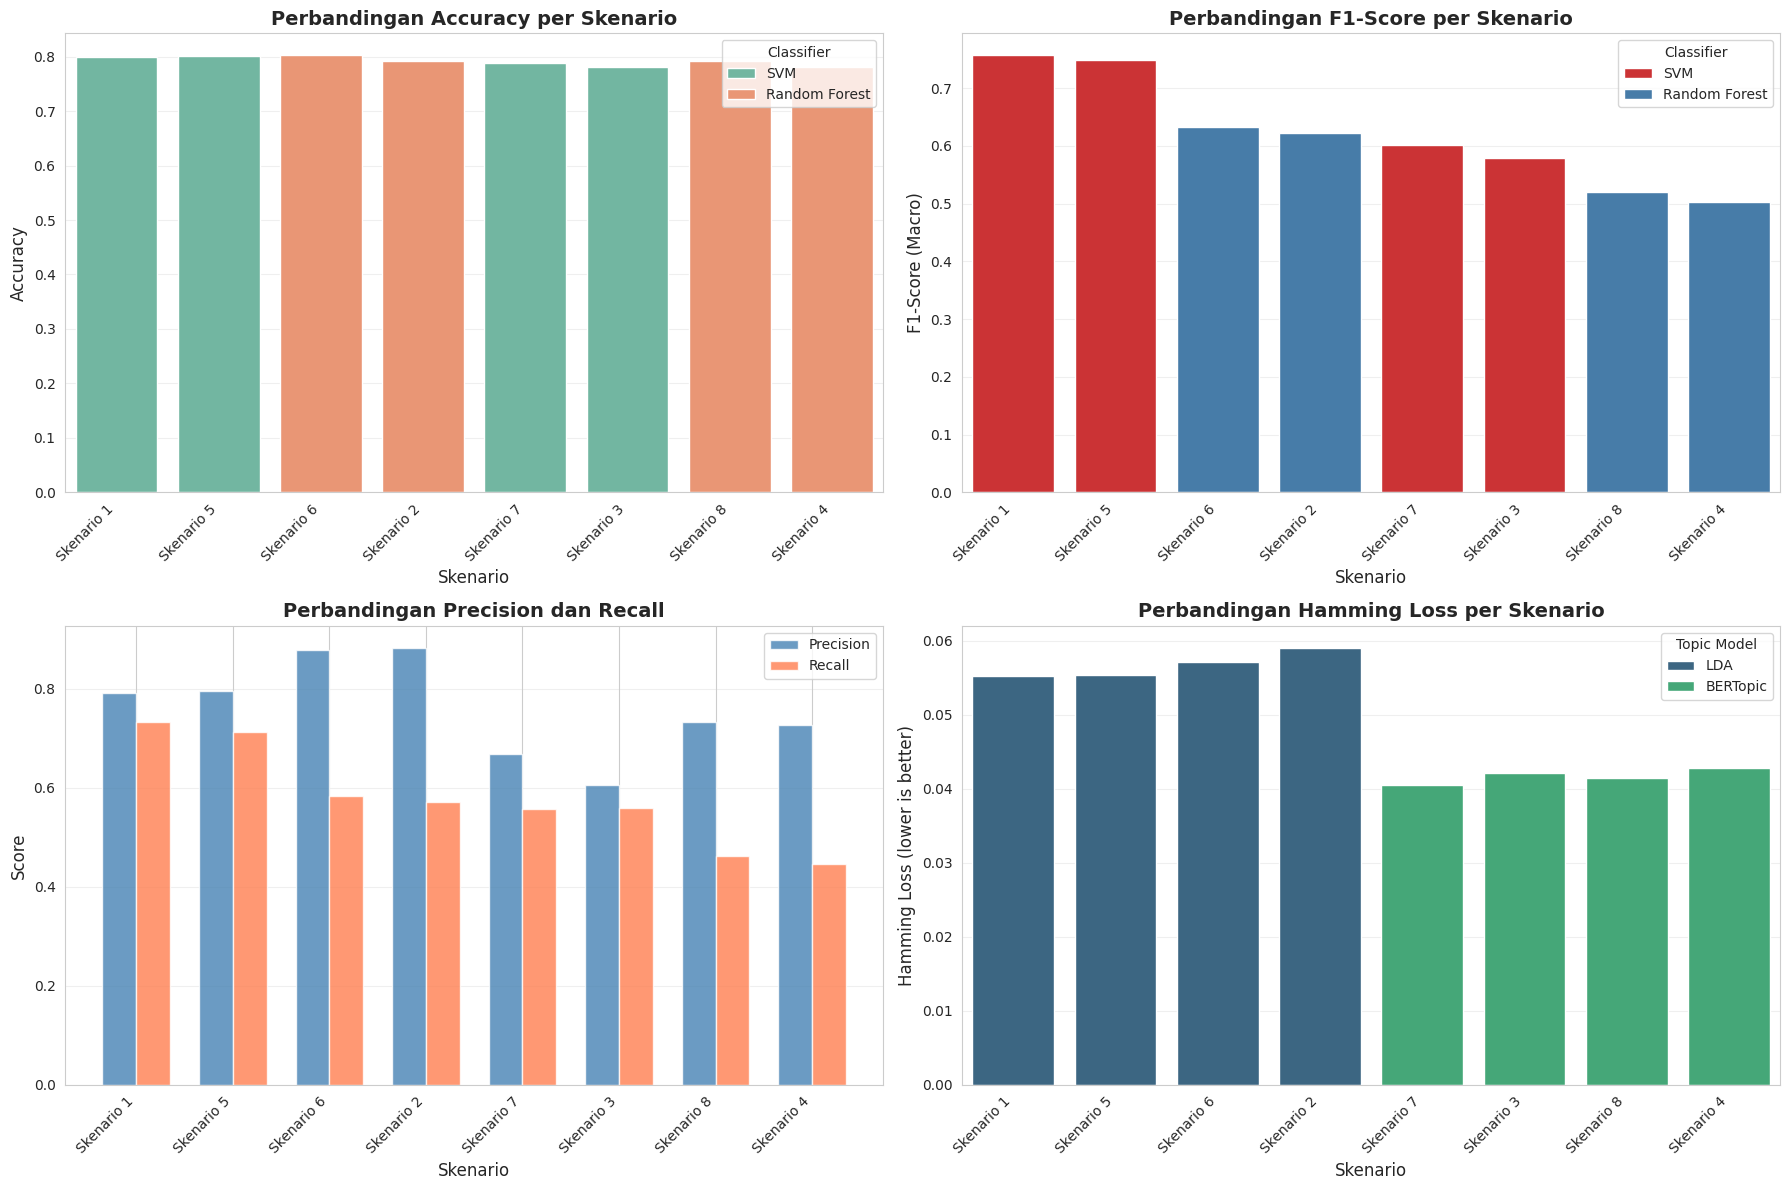

In [ ]:
print("\n" + "="*80)
print("VISUALISASI PERBANDINGAN PERFORMA")
print("="*80 + "\n")

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Accuracy Comparison
ax1 = axes[0, 0]
sns.barplot(data=df_comparison, x='Skenario', y='Accuracy',
            hue='Classifier', palette='Set2', ax=ax1)
ax1.set_title('Perbandingan Accuracy per Skenario', fontsize=14, fontweight='bold')
ax1.set_xlabel('Skenario', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend(title='Classifier')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: F1-Score Comparison
ax2 = axes[0, 1]
sns.barplot(data=df_comparison, x='Skenario', y='F1-Score',
            hue='Classifier', palette='Set1', ax=ax2)
ax2.set_title('Perbandingan F1-Score per Skenario', fontsize=14, fontweight='bold')
ax2.set_xlabel('Skenario', fontsize=12)
ax2.set_ylabel('F1-Score (Macro)', fontsize=12)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
ax2.legend(title='Classifier')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: Precision & Recall
ax3 = axes[1, 0]
x_pos = np.arange(len(df_comparison))
width = 0.35
ax3.bar(x_pos - width/2, df_comparison['Precision'], width,
        label='Precision', alpha=0.8, color='steelblue')
ax3.bar(x_pos + width/2, df_comparison['Recall'], width,
        label='Recall', alpha=0.8, color='coral')
ax3.set_title('Perbandingan Precision dan Recall', fontsize=14, fontweight='bold')
ax3.set_xlabel('Skenario', fontsize=12)
ax3.set_ylabel('Score', fontsize=12)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(df_comparison['Skenario'], rotation=45, ha='right')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Hamming Loss
ax4 = axes[1, 1]
sns.barplot(data=df_comparison, x='Skenario', y='Hamming Loss',
            hue='Topic Model', palette='viridis', ax=ax4)
ax4.set_title('Perbandingan Hamming Loss per Skenario', fontsize=14, fontweight='bold')
ax4.set_xlabel('Skenario', fontsize=12)
ax4.set_ylabel('Hamming Loss (lower is better)', fontsize=12)
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, ha='right')
ax4.legend(title='Topic Model')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Grafik perbandingan disimpan: /content/model_comparison.png")
plt.show()

# Penyimpanan Model Terbaik

In [ ]:
print("\n" + "="*80)
print("PENYIMPANAN MODEL TERBAIK")
print("="*80 + "\n")

# Ambil model terbaik
best_scenario_name = best_scenario['Skenario']
best_model_data = all_results[best_scenario_name]['results']

# Simpan vectorizer
vectorizer_path = '/content/best_tfidf_vectorizer.pkl'
joblib.dump(best_model_data['vectorizer'], vectorizer_path)
print(f"✅ TF-IDF Vectorizer disimpan: {vectorizer_path}")

# Simpan models (semua label)
models_path = '/content/best_models.pkl'
joblib.dump(best_model_data['models'], models_path)
print(f"✅ Models disimpan: {models_path}")

# Simpan MultiLabelBinarizer
if best_scenario['Topic Model'] == 'LDA':
    mlb_path = '/content/best_mlb_lda.pkl'
    joblib.dump(mlb_lda, mlb_path)
else:
    mlb_path = '/content/best_mlb_bertopic.pkl'
    joblib.dump(mlb_bertopic, mlb_path)

print(f"✅ MultiLabelBinarizer disimpan: {mlb_path}")

# Simpan hasil comparison
df_comparison.to_csv('/content/model_comparison_results.csv', index=False)
print(f"✅ Hasil perbandingan disimpan: /content/model_comparison_results.csv")

# Simpan informasi model terbaik
best_model_info = {
    'scenario': best_scenario_name,
    'topic_model': best_scenario['Topic Model'],
    'classifier': best_scenario['Classifier'],
    'split_ratio': best_scenario['Split Ratio'],
    'metrics': best_model_data['metrics'],
    'best_params': best_model_data['best_params']
}

import json
with open('/content/best_model_info.json', 'w') as f:
    json.dump(best_model_info, f, indent=4)
print(f"✅ Info model terbaik disimpan: /content/best_model_info.json")



PENYIMPANAN MODEL TERBAIK

✅ TF-IDF Vectorizer disimpan: /content/best_tfidf_vectorizer.pkl
✅ Models disimpan: /content/best_models.pkl
✅ MultiLabelBinarizer disimpan: /content/best_mlb_lda.pkl
✅ Hasil perbandingan disimpan: /content/model_comparison_results.csv
✅ Info model terbaik disimpan: /content/best_model_info.json


# Ringkasan Akhir

In [ ]:
print("\n" + "="*80)
print("10. RINGKASAN AKHIR")
print("="*80 + "\n")

print("PROSES PEMBANGUNAN MODEL KLASIFIKASI SELESAI!")
print("\nRingkasan:")
print(f"  • Total skenario yang diuji: {len(scenarios)}")
print(f"  • Model terbaik: {best_scenario_name}")
print(f"  • Topic modeling: {best_scenario['Topic Model']}")
print(f"  • Algoritma klasifikasi: {best_scenario['Classifier']}")
print(f"  • F1-Score: {best_scenario['F1-Score']:.4f}")
print(f"\nFile yang disimpan:")
print(f"  1. TF-IDF Vectorizer: {vectorizer_path}")
print(f"  2. Models: {models_path}")
print(f"  3. MultiLabelBinarizer: {mlb_path}")
print(f"  4. Model comparison: /content/model_comparison_results.csv")
print(f"  5. Best model info: /content/best_model_info.json")
print(f"  6. Visualization: /content/model_comparison.png")
print(f"  7. LDA validation data: /content/lda_validation_data.csv")
print(f"  8. BERTopic validation data: /content/bertopic_validation_data.csv")

print("\n" + "="*80)
print("TAHAP SELANJUTNYA: IMPLEMENTASI SISTEM WEB DAN VALIDASI AKHIR")
print("="*80)


10. RINGKASAN AKHIR

PROSES PEMBANGUNAN MODEL KLASIFIKASI SELESAI!

Ringkasan:
  • Total skenario yang diuji: 8
  • Model terbaik: Skenario 1
  • Topic modeling: LDA
  • Algoritma klasifikasi: SVM
  • F1-Score: 0.7572

File yang disimpan:
  1. TF-IDF Vectorizer: /content/best_tfidf_vectorizer.pkl
  2. Models: /content/best_models.pkl
  3. MultiLabelBinarizer: /content/best_mlb_lda.pkl
  4. Model comparison: /content/model_comparison_results.csv
  5. Best model info: /content/best_model_info.json
  6. Visualization: /content/model_comparison.png
  7. LDA validation data: /content/lda_validation_data.csv
  8. BERTopic validation data: /content/bertopic_validation_data.csv

TAHAP SELANJUTNYA: IMPLEMENTASI SISTEM WEB DAN VALIDASI AKHIR


# TRAINING + VALIDASI + CEK OVERFITTING

In [ ]:
import numpy as np
import pandas as pd
import joblib, json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, hamming_loss, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42

# ============================================================================
# FUNGSI HELPER (TIDAK BERUBAH)
# ============================================================================

def create_tfidf_vectorizer():
    return TfidfVectorizer(
        max_features=5000, ngram_range=(1, 2),
        min_df=2, max_df=0.95
    )

def get_classifier(classifier_name):
    if classifier_name == 'SVM':
        param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 'auto']}
        base_model = SVC(random_state=RANDOM_SEED, probability=True)
    elif classifier_name == 'Random Forest':
        param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None],
                      'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}
        base_model = RandomForestClassifier(random_state=RANDOM_SEED)
    return base_model, param_grid

def compute_metrics(y_true, y_pred):
    return {
        'accuracy':        accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred,    average='macro', zero_division=0),
        'f1_macro':        f1_score(y_true, y_pred,        average='macro', zero_division=0),
        'hamming_loss':    hamming_loss(y_true, y_pred),
    }

# ============================================================================
# FUNGSI TRAINING + EVALUASI — SEKARANG RETURN JUGA TRAIN METRICS
# ============================================================================

def train_and_evaluate_model(X_train, X_test, y_train, y_test, classifier_name, mlb):

    print(f"\n{'='*80}")
    print(f"Training model: {classifier_name}")
    print(f"{'='*80}")

    # TF-IDF
    print("  Proses TF-IDF Vectorization...")
    vectorizer = create_tfidf_vectorizer()
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf  = vectorizer.transform(X_test)
    print(f"    ✓ Shape X_train: {X_train_tfidf.shape}")
    print(f"    ✓ Shape X_test : {X_test_tfidf.shape}")

    base_model, param_grid = get_classifier(classifier_name)
    grid_search = GridSearchCV(base_model, param_grid, cv=5,
                               scoring='f1_macro', n_jobs=-1, verbose=0)

    print(f"\n  Proses Grid Search CV untuk hyperparameter tuning...")
    print(f"\n  Training model untuk {y_train.shape[1]} label...")

    models = []
    best_params_list = []

    for i in range(y_train.shape[1]):
        print(f"    Training label {i+1}/{y_train.shape[1]}: {mlb.classes_[i]}", end=" ")
        grid_search.fit(X_train_tfidf, y_train[:, i])
        models.append(grid_search.best_estimator_)
        best_params_list.append(grid_search.best_params_)
        print("✓")

    print(f"\n  ✅ Training selesai!")

    # ── PREDIKSI TEST ──────────────────────────────────────────────────────
    print(f"\n  Proses prediksi pada data test...")
    y_pred_test = np.zeros_like(y_test)
    for i, model in enumerate(models):
        y_pred_test[:, i] = model.predict(X_test_tfidf)
    print(f"    ✓ Prediksi test selesai")

    # ── PREDIKSI TRAIN (untuk cek overfitting) ─────────────────────────────
    print(f"  Proses prediksi pada data train...")
    y_pred_train = np.zeros_like(y_train)
    for i, model in enumerate(models):
        y_pred_train[:, i] = model.predict(X_train_tfidf)
    print(f"    ✓ Prediksi train selesai")

    # ── HITUNG METRIK ──────────────────────────────────────────────────────
    test_metrics  = compute_metrics(y_test,  y_pred_test)
    train_metrics = compute_metrics(y_train, y_pred_train)

    # Tampilkan test metrics
    print(f"\n  {'='*60}")
    print(f"  HASIL EVALUASI MODEL (TEST SET)")
    print(f"  {'='*60}")
    print(f"  Accuracy         : {test_metrics['accuracy']:.4f} ({test_metrics['accuracy']*100:.2f}%)")
    print(f"  Precision (Macro): {test_metrics['precision_macro']:.4f}")
    print(f"  Recall (Macro)   : {test_metrics['recall_macro']:.4f}")
    print(f"  F1-Score (Macro) : {test_metrics['f1_macro']:.4f}")
    print(f"  Hamming Loss     : {test_metrics['hamming_loss']:.4f}")

    # ── PER-LABEL METRICS ──────────────────────────────────────────────────
    print(f"\n  {'='*60}")
    print(f"  METRIK PER LABEL")
    print(f"  {'='*60}")
    per_label_metrics = []
    for i, label_name in enumerate(mlb.classes_):
        acc  = accuracy_score(y_test[:, i], y_pred_test[:, i])
        prec = precision_score(y_test[:, i], y_pred_test[:, i], zero_division=0)
        rec  = recall_score(y_test[:, i], y_pred_test[:, i],    zero_division=0)
        f1l  = f1_score(y_test[:, i], y_pred_test[:, i],        zero_division=0)
        print(f"\n  Label: {label_name}")
        print(f"    Accuracy : {acc:.4f}")
        print(f"    Precision: {prec:.4f}")
        print(f"    Recall   : {rec:.4f}")
        print(f"    F1-Score : {f1l:.4f}")
        per_label_metrics.append({'label': label_name, 'accuracy': acc,
                                  'precision': prec, 'recall': rec, 'f1_score': f1l})

    return {
        'vectorizer': vectorizer,
        'models': models,
        'best_params': best_params_list,
        'metrics': test_metrics,           # ← test metrics
        'train_metrics': train_metrics,    # ← train metrics (untuk overfitting)
        'per_label_metrics': per_label_metrics,
        'y_test':  y_test,
        'y_pred':  y_pred_test,
        'y_train': y_train,
        'y_pred_train': y_pred_train,
    }

# ============================================================================
# FUNGSI VALIDASI
# ============================================================================

def validate_system(df_val, vectorizer, models, mlb, topic_model_name):
    """Evaluasi model terbaik pada data validation (unseen)"""

    print(f"\nValidasi untuk Topic Model: {topic_model_name}")
    print(f"Jumlah data validasi: {len(df_val):,} ulasan")

    # Siapkan X & y validasi
    X_val = df_val['final_text'].values

    aspect_columns = ['User Experience', 'Service Quality'] if topic_model_name == 'LDA' \
                     else ['User Experience', 'Service Quality', 'System Reliability']

    y_val_raw = []
    for _, row in df_val.iterrows():
        labels = []
        for asp in aspect_columns:
            v = row[asp]
            if v == 1: labels.append(f"{asp}_positive")
            elif v == 2: labels.append(f"{asp}_negative")
        y_val_raw.append(labels)

    y_val = mlb.transform(y_val_raw)
    print(f"Shape X_val: {len(X_val)}")
    print(f"Shape y_val: {y_val.shape}")

    # Transform & prediksi
    print("\n  Proses TF-IDF transformation...")
    X_val_tfidf = vectorizer.transform(X_val)
    print(f"    ✓ Shape X_val_tfidf: {X_val_tfidf.shape}")

    print("\n  Proses prediksi...")
    y_pred_val = np.zeros_like(y_val)
    for i, model in enumerate(models):
        y_pred_val[:, i] = model.predict(X_val_tfidf)
    print(f"    ✓ Prediksi selesai")

    # Metrik
    val_metrics = compute_metrics(y_val, y_pred_val)

    print(f"\n  {'='*60}")
    print(f"  HASIL VALIDASI SISTEM")
    print(f"  {'='*60}")
    print(f"  Accuracy         : {val_metrics['accuracy']:.4f} ({val_metrics['accuracy']*100:.2f}%)")
    print(f"  Precision (Macro): {val_metrics['precision_macro']:.4f}")
    print(f"  Recall (Macro)   : {val_metrics['recall_macro']:.4f}")
    print(f"  F1-Score (Macro) : {val_metrics['f1_macro']:.4f}")
    print(f"  Hamming Loss     : {val_metrics['hamming_loss']:.4f}")

    # Per-label
    print(f"\n  {'='*60}")
    print(f"  METRIK PER LABEL (VALIDATION)")
    print(f"  {'='*60}")
    per_label = []
    for i, lbl in enumerate(mlb.classes_):
        acc  = accuracy_score(y_val[:, i], y_pred_val[:, i])
        prec = precision_score(y_val[:, i], y_pred_val[:, i], zero_division=0)
        rec  = recall_score(y_val[:, i], y_pred_val[:, i],    zero_division=0)
        f1l  = f1_score(y_val[:, i], y_pred_val[:, i],        zero_division=0)
        print(f"\n  Label: {lbl}")
        print(f"    Accuracy : {acc:.4f}  Precision: {prec:.4f}")
        print(f"    Recall   : {rec:.4f}  F1-Score : {f1l:.4f}")
        per_label.append({'label': lbl, 'accuracy': acc, 'precision': prec,
                          'recall': rec, 'f1_score': f1l})

    # Confusion matrices
    import os
    os.makedirs('/content/confusion_matrices_validation', exist_ok=True)
    n_cols = 2
    n_rows = (len(mlb.classes_) + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4*n_rows))
    axes = axes.flatten()
    for i, lbl in enumerate(mlb.classes_):
        cm = confusion_matrix(y_val[:, i], y_pred_val[:, i])
        ConfusionMatrixDisplay(cm, display_labels=['Tidak Ada','Ada']).plot(
            ax=axes[i], colorbar=False, cmap='Blues')
        axes[i].set_title(lbl, fontsize=10, fontweight='bold')
    for j in range(len(mlb.classes_), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'Confusion Matrix — Validation Set\n{topic_model_name}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/confusion_matrices_validation/cm_validation.png',
                dpi=200, bbox_inches='tight')
    print(f"\n  ✅ Confusion matrices validasi disimpan di /content/confusion_matrices_validation/")
    plt.show()

    return {'metrics': val_metrics, 'per_label_metrics': per_label,
            'y_true': y_val, 'y_pred': y_pred_val}


# FUNGSI CEK OVERFITTING

In [ ]:
def check_overfitting(all_results, validation_results_by_scenario=None):
    """
    Membandingkan Train vs Test vs Validation metrics untuk deteksi overfitting.

    Kriteria:
      Train F1 - Test F1 > 0.10  → overfit
      Test  F1 - Val  F1 > 0.05  → suspicious (validasi jauh lebih buruk)
    """

    print("\n" + "="*80)
    print("CEK OVERFITTING")
    print("="*80 + "\n")

    OVERFIT_THRESHOLD  = 0.10   # selisih train-test
    VAL_THRESHOLD      = 0.05   # selisih test-validation

    rows = []
    for sname, data in all_results.items():
        train_f1 = data['results']['train_metrics']['f1_macro']
        test_f1  = data['results']['metrics']['f1_macro']
        diff     = train_f1 - test_f1

        val_f1   = None
        val_diff = None
        if validation_results_by_scenario and sname in validation_results_by_scenario:
            val_f1   = validation_results_by_scenario[sname]['metrics']['f1_macro']
            val_diff = test_f1 - val_f1

        if diff > OVERFIT_THRESHOLD:
            status = "⚠️  OVERFIT"
        elif diff < -0.02:
            status = "🔵 UNDERFIT"
        else:
            status = "✅ NORMAL"

        val_status = ""
        if val_diff is not None:
            if val_diff > VAL_THRESHOLD:
                val_status = " ⚠️ Val drop"
            else:
                val_status = " ✅ Val OK"

        rows.append({
            'Skenario'     : sname,
            'Topic'        : data['config']['topic_model'],
            'Classifier'   : data['config']['classifier'],
            'Split'        : data['config']['split_ratio'],
            'Train F1'     : train_f1,
            'Test F1'      : test_f1,
            'Gap (Tr-Te)'  : diff,
            'Val F1'       : val_f1 if val_f1 is not None else '-',
            'Gap (Te-Val)' : round(val_diff,4) if val_diff is not None else '-',
            'Status'       : status + val_status,
        })

    df_ov = pd.DataFrame(rows)

    print(f"  Threshold Overfit  : Train F1 - Test F1 > {OVERFIT_THRESHOLD:.2f}")
    print(f"  Threshold Val Drop : Test F1  - Val F1  > {VAL_THRESHOLD:.2f}\n")

    print(f"  {'Skenario':<14} {'Topic':<10} {'Clf':<18} {'Split':<8} "
          f"{'Train F1':>9} {'Test F1':>9} {'Gap':>7} {'Val F1':>9} {'Val Gap':>9}  Status")
    print(f"  {'-'*120}")
    for _, r in df_ov.iterrows():
        val_f1_str  = f"{r['Val F1']:.4f}"  if isinstance(r['Val F1'],  float) else str(r['Val F1'])
        val_gap_str = f"{r['Gap (Te-Val)']:.4f}" if isinstance(r['Gap (Te-Val)'], float) else str(r['Gap (Te-Val)'])
        print(f"  {r['Skenario']:<14} {r['Topic']:<10} {r['Classifier']:<18} {r['Split']:<8} "
              f"{r['Train F1']:>9.4f} {r['Test F1']:>9.4f} {r['Gap (Tr-Te)']:>7.4f} "
              f"{val_f1_str:>9} {val_gap_str:>9}  {r['Status']}")

    # ── VISUALISASI ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Train vs Test F1
    ax1 = axes[0]
    x   = np.arange(len(df_ov))
    w   = 0.35
    b1  = ax1.bar(x - w/2, df_ov['Train F1'], w, label='Train F1', color='#4f86c6', alpha=0.85)
    b2  = ax1.bar(x + w/2, df_ov['Test F1'],  w, label='Test F1',  color='#f4845f', alpha=0.85)
    for bar in list(b1)+list(b2):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
    ax1.axhline(y=0, color='gray', linewidth=0.5)
    ax1.set_title('Train vs Test F1-Score\n(Gap besar = Overfitting)',
                  fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_ov['Skenario'], rotation=45, ha='right', fontsize=9)
    ax1.set_ylabel('F1-Score (Macro)')
    ax1.set_ylim(0, 1.1)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    ax1.axhline(y=0.9, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Ref 0.9')

    # Highlight overfit bars
    for i, row in df_ov.iterrows():
        if row['Gap (Tr-Te)'] > OVERFIT_THRESHOLD:
            ax1.axvspan(i - 0.5, i + 0.5, alpha=0.08, color='red')

    # Plot 2: Gap bar chart
    ax2 = axes[1]
    colors = ['#e74c3c' if g > OVERFIT_THRESHOLD else '#2ecc71' if g < 0
              else '#f39c12' for g in df_ov['Gap (Tr-Te)']]
    bars = ax2.bar(x, df_ov['Gap (Tr-Te)'], color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
    for bar in bars:
        h = bar.get_height()
        ax2.text(bar.get_x()+bar.get_width()/2,
                 h + 0.003 if h >= 0 else h - 0.012,
                 f'{h:.4f}', ha='center', va='bottom', fontsize=8)
    ax2.axhline(y=OVERFIT_THRESHOLD, color='red', linestyle='--', linewidth=1.5,
                label=f'Threshold overfit ({OVERFIT_THRESHOLD})')
    ax2.axhline(y=0, color='black', linewidth=0.8)
    ax2.set_title('Gap Train-Test F1\n(Di atas garis merah = Overfit)',
                  fontsize=12, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(df_ov['Skenario'], rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Gap (Train F1 - Test F1)')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)

    from matplotlib.patches import Patch
    legend_els = [Patch(color='#e74c3c', label='Overfit'),
                  Patch(color='#f39c12', label='Normal'),
                  Patch(color='#2ecc71', label='Underfit')]
    ax2.legend(handles=legend_els, loc='upper right')

    plt.tight_layout()
    plt.savefig('/content/overfitting_analysis.png', dpi=200, bbox_inches='tight')
    print(f"\n  ✅ Grafik overfitting disimpan: /content/overfitting_analysis.png")
    plt.show()

    df_ov.to_csv('/content/overfitting_analysis.csv', index=False)
    print(f"  ✅ Tabel overfitting disimpan : /content/overfitting_analysis.csv")

    return df_ov



# VALIDASI MODEL


LOAD MODEL TERBAIK YANG SUDAH DI-TRAINING

✅ Model berhasil di-load:
  Scenario: Skenario 1
  Topic Model: LDA
  Classifier: SVM
  F1-Score (Test): 0.7572

LOAD DATA VALIDATION

✅ LDA Validation: 1,622 ulasan
✅ BERTopic Validation: 1,622 ulasan

✅ Menggunakan data validasi: LDA

################################################################################
# VALIDASI MODEL DENGAN DATA UNSEEN (10%)
################################################################################

Validasi untuk Topic Model: LDA
Jumlah data validasi: 1,622 ulasan
Shape X_val: 1622
Shape y_val: (1622, 4)

  Proses TF-IDF transformation...
    ✓ Shape X_val_tfidf: (1622, 5000)

  Proses prediksi...
    ✓ Prediksi selesai

  HASIL VALIDASI SISTEM
  Accuracy         : 0.8120 (81.20%)
  Precision (Macro): 0.7560
  Recall (Macro)   : 0.7091
  F1-Score (Macro) : 0.7307
  Hamming Loss     : 0.0536

  METRIK PER LABEL (VALIDATION)

  Label: Service Quality_negative
    Accuracy : 0.9840  Precision: 0.5556
    R

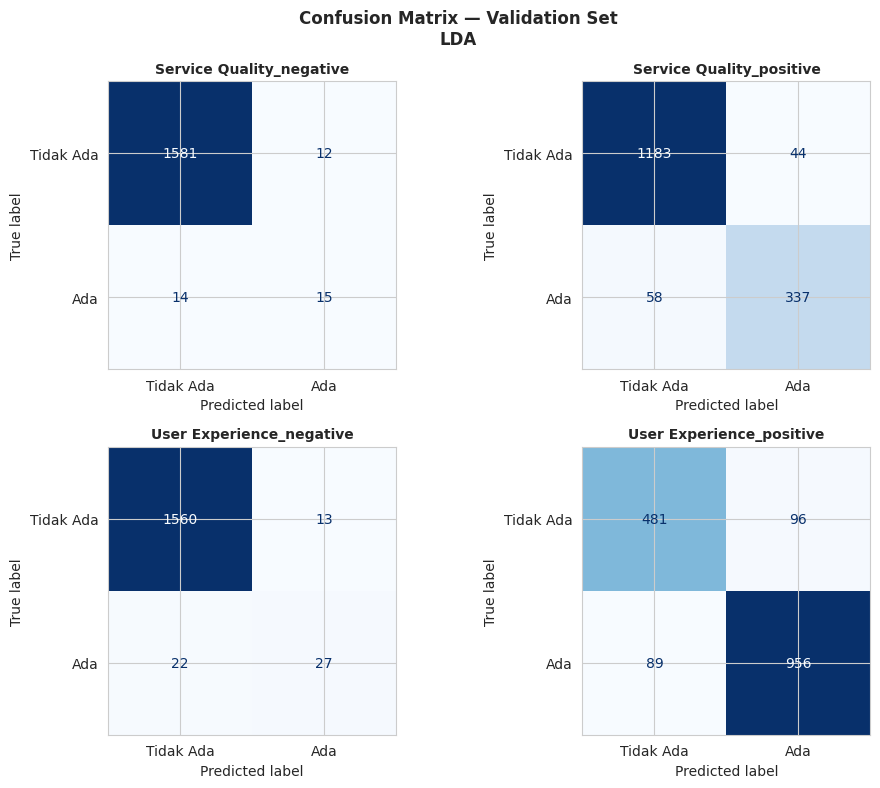


PERBANDINGAN: TEST vs VALIDATION

      Metric     Test  Validation
    Accuracy 0.800000    0.811961
   Precision 0.791208    0.755954
      Recall 0.734021    0.709065
    F1-Score 0.757176    0.730698
Hamming Loss 0.055308    0.053637

✅ Grafik disimpan: /content/test_vs_validation.png


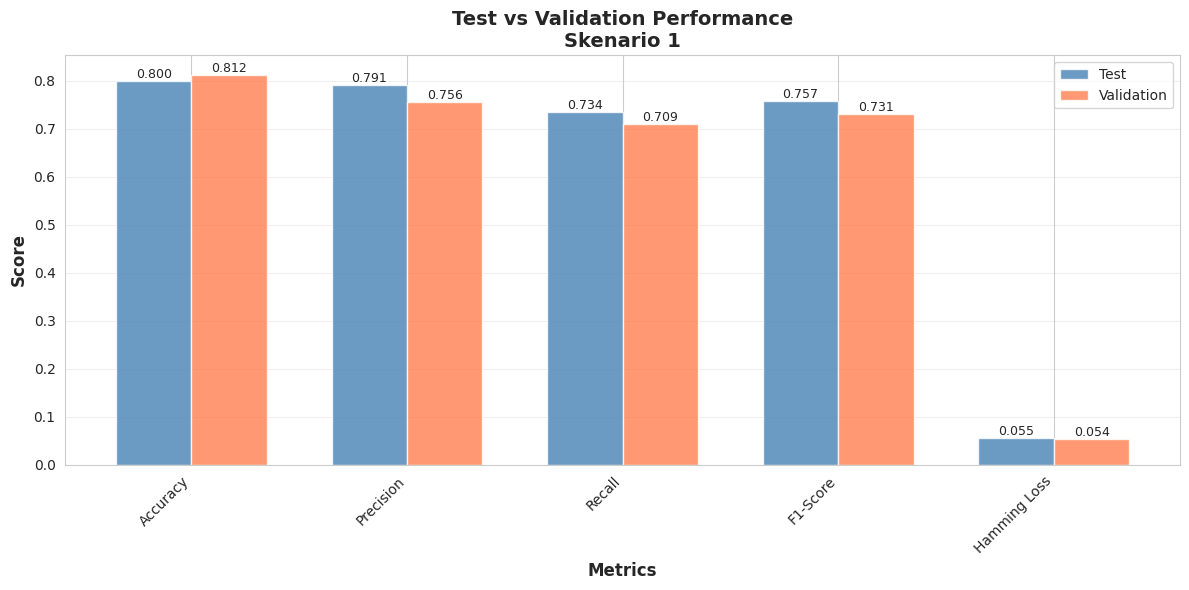


CEK OVERFITTING

Test F1-Score      : 0.7572
Validation F1-Score: 0.7307
Selisih            : 0.0265 (2.65%)

KESIMPULAN: ✅ Model STABIL - Tidak ada overfitting

✅ Hasil disimpan: /content/validation_summary.csv

✅ VALIDASI SELESAI!


In [ ]:

import numpy as np
import pandas as pd
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, hamming_loss, confusion_matrix, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42

# ============================================================================
# FUNGSI HELPER (SAMA SEPERTI SEBELUMNYA)
# ============================================================================

def compute_metrics(y_true, y_pred):
    return {
        'accuracy':        accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    recall_score(y_true, y_pred,    average='macro', zero_division=0),
        'f1_macro':        f1_score(y_true, y_pred,        average='macro', zero_division=0),
        'hamming_loss':    hamming_loss(y_true, y_pred),
    }

def validate_system(df_val, vectorizer, models, mlb, topic_model_name):
    """Evaluasi model terbaik pada data validation (unseen)"""

    print(f"\nValidasi untuk Topic Model: {topic_model_name}")
    print(f"Jumlah data validasi: {len(df_val):,} ulasan")

    # Siapkan X & y validasi
    X_val = df_val['final_text'].values

    aspect_columns = ['User Experience', 'Service Quality'] if topic_model_name == 'LDA' \
                     else ['User Experience', 'Service Quality', 'System Reliability']

    y_val_raw = []
    for _, row in df_val.iterrows():
        labels = []
        for asp in aspect_columns:
            v = row[asp]
            if v == 1: labels.append(f"{asp}_positive")
            elif v == 2: labels.append(f"{asp}_negative")
        y_val_raw.append(labels)

    y_val = mlb.transform(y_val_raw)
    print(f"Shape X_val: {len(X_val)}")
    print(f"Shape y_val: {y_val.shape}")

    # Transform & prediksi
    print("\n  Proses TF-IDF transformation...")
    X_val_tfidf = vectorizer.transform(X_val)
    print(f"    ✓ Shape X_val_tfidf: {X_val_tfidf.shape}")

    print("\n  Proses prediksi...")
    y_pred_val = np.zeros_like(y_val)
    for i, model in enumerate(models):
        y_pred_val[:, i] = model.predict(X_val_tfidf)
    print(f"    ✓ Prediksi selesai")

    # Metrik
    val_metrics = compute_metrics(y_val, y_pred_val)

    print(f"\n  {'='*60}")
    print(f"  HASIL VALIDASI SISTEM")
    print(f"  {'='*60}")
    print(f"  Accuracy         : {val_metrics['accuracy']:.4f} ({val_metrics['accuracy']*100:.2f}%)")
    print(f"  Precision (Macro): {val_metrics['precision_macro']:.4f}")
    print(f"  Recall (Macro)   : {val_metrics['recall_macro']:.4f}")
    print(f"  F1-Score (Macro) : {val_metrics['f1_macro']:.4f}")
    print(f"  Hamming Loss     : {val_metrics['hamming_loss']:.4f}")

    # Per-label
    print(f"\n  {'='*60}")
    print(f"  METRIK PER LABEL (VALIDATION)")
    print(f"  {'='*60}")
    per_label = []
    for i, lbl in enumerate(mlb.classes_):
        acc  = accuracy_score(y_val[:, i], y_pred_val[:, i])
        prec = precision_score(y_val[:, i], y_pred_val[:, i], zero_division=0)
        rec  = recall_score(y_val[:, i], y_pred_val[:, i],    zero_division=0)
        f1l  = f1_score(y_val[:, i], y_pred_val[:, i],        zero_division=0)
        print(f"\n  Label: {lbl}")
        print(f"    Accuracy : {acc:.4f}  Precision: {prec:.4f}")
        print(f"    Recall   : {rec:.4f}  F1-Score : {f1l:.4f}")
        per_label.append({'label': lbl, 'accuracy': acc, 'precision': prec,
                          'recall': rec, 'f1_score': f1l})

    # Confusion matrices
    import os
    os.makedirs('/content/confusion_matrices_validation', exist_ok=True)
    n_cols = 2
    n_rows = (len(mlb.classes_) + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 4*n_rows))
    axes = axes.flatten()
    for i, lbl in enumerate(mlb.classes_):
        cm = confusion_matrix(y_val[:, i], y_pred_val[:, i])
        ConfusionMatrixDisplay(cm, display_labels=['Tidak Ada','Ada']).plot(
            ax=axes[i], colorbar=False, cmap='Blues')
        axes[i].set_title(lbl, fontsize=10, fontweight='bold')
    for j in range(len(mlb.classes_), len(axes)):
        axes[j].set_visible(False)
    plt.suptitle(f'Confusion Matrix — Validation Set\n{topic_model_name}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/confusion_matrices_validation/cm_validation.png',
                dpi=200, bbox_inches='tight')
    print(f"\n  ✅ Confusion matrices validasi disimpan di /content/confusion_matrices_validation/")
    plt.show()

    return {'metrics': val_metrics, 'per_label_metrics': per_label,
            'y_true': y_val, 'y_pred': y_pred_val}


# ============================================================================
# MAIN EXECUTION: LOAD MODEL & VALIDASI
# ============================================================================

print("\n" + "="*80)
print("LOAD MODEL TERBAIK YANG SUDAH DI-TRAINING")
print("="*80 + "\n")

# Load model terbaik
vectorizer = joblib.load('/content/best_tfidf_vectorizer.pkl')
models = joblib.load('/content/best_models.pkl')

# Load info model
with open('/content/best_model_info.json', 'r') as f:
    best_model_info = json.load(f)

print("✅ Model berhasil di-load:")
print(f"  Scenario: {best_model_info['scenario']}")
print(f"  Topic Model: {best_model_info['topic_model']}")
print(f"  Classifier: {best_model_info['classifier']}")
print(f"  F1-Score (Test): {best_model_info['metrics']['f1_macro']:.4f}")

# ============================================================================
# LOAD DATA VALIDATION
# ============================================================================

print("\n" + "="*80)
print("LOAD DATA VALIDATION")
print("="*80 + "\n")

df_lda_validation = pd.read_csv('/content/lda_validation_data.csv')
df_bertopic_validation = pd.read_csv('/content/bertopic_validation_data.csv')

print(f"✅ LDA Validation: {len(df_lda_validation):,} ulasan")
print(f"✅ BERTopic Validation: {len(df_bertopic_validation):,} ulasan")

# Pilih sesuai model terbaik
if best_model_info['topic_model'] == 'LDA':
    validation_df = df_lda_validation
    mlb = joblib.load('/content/best_mlb_lda.pkl')
    topic_model_name = 'LDA'
else:
    validation_df = df_bertopic_validation
    mlb = joblib.load('/content/best_mlb_bertopic.pkl')
    topic_model_name = 'BERTopic'

print(f"\n✅ Menggunakan data validasi: {topic_model_name}")

# ============================================================================
# VALIDASI
# ============================================================================

print("\n" + "#"*80)
print("# VALIDASI MODEL DENGAN DATA UNSEEN (10%)")
print("#"*80)

validation_results = validate_system(
    validation_df,
    vectorizer,
    models,
    mlb,
    topic_model_name
)

# ============================================================================
# PERBANDINGAN TEST vs VALIDATION
# ============================================================================

print("\n" + "="*80)
print("PERBANDINGAN: TEST vs VALIDATION")
print("="*80 + "\n")

test_metrics = best_model_info['metrics']
val_metrics = validation_results['metrics']

comparison_data = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Hamming Loss'],
    'Test': [
        test_metrics['accuracy'],
        test_metrics['precision_macro'],
        test_metrics['recall_macro'],
        test_metrics['f1_macro'],
        test_metrics['hamming_loss']
    ],
    'Validation': [
        val_metrics['accuracy'],
        val_metrics['precision_macro'],
        val_metrics['recall_macro'],
        val_metrics['f1_macro'],
        val_metrics['hamming_loss']
    ]
})

print(comparison_data.to_string(index=False))

# Visualisasi
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
x = np.arange(len(comparison_data))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_data['Test'], width,
               label='Test', alpha=0.8, color='steelblue')
bars2 = ax.bar(x + width/2, comparison_data['Validation'], width,
               label='Validation', alpha=0.8, color='coral')

ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title(f'Test vs Validation Performance\n{best_model_info["scenario"]}',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_data['Metric'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/content/test_vs_validation.png', dpi=300, bbox_inches='tight')
print("\n✅ Grafik disimpan: /content/test_vs_validation.png")
plt.show()

# ============================================================================
# CEK OVERFITTING
# ============================================================================

print("\n" + "="*80)
print("CEK OVERFITTING")
print("="*80 + "\n")

diff_f1 = abs(test_metrics['f1_macro'] - val_metrics['f1_macro'])

print(f"Test F1-Score      : {test_metrics['f1_macro']:.4f}")
print(f"Validation F1-Score: {val_metrics['f1_macro']:.4f}")
print(f"Selisih            : {diff_f1:.4f} ({diff_f1*100:.2f}%)")

if diff_f1 < 0.05:
    conclusion = "✅ Model STABIL - Tidak ada overfitting"
elif diff_f1 < 0.10:
    conclusion = "⚠️ Model CUKUP STABIL - Overfitting ringan"
else:
    conclusion = "❌ Model OVERFITTING - Performa validation jauh lebih buruk"

print(f"\nKESIMPULAN: {conclusion}")

# ============================================================================
# SIMPAN HASIL
# ============================================================================

validation_results['metrics']['test_f1'] = test_metrics['f1_macro']
validation_results['metrics']['overfitting_gap'] = diff_f1

validation_summary = pd.DataFrame([{
    'Model': best_model_info['scenario'],
    'Topic_Model': topic_model_name,
    'Classifier': best_model_info['classifier'],
    'Test_F1': test_metrics['f1_macro'],
    'Validation_F1': val_metrics['f1_macro'],
    'Gap': diff_f1,
    'Overfitting': 'Yes' if diff_f1 > 0.10 else 'No'
}])

validation_summary.to_csv('/content/validation_summary.csv', index=False)
print("\n✅ Hasil disimpan: /content/validation_summary.csv")

print("\n" + "="*80)
print("✅ VALIDASI SELESAI!")
print("="*80)

In [ ]:
# Load model
vectorizer = joblib.load('/content/best_tfidf_vectorizer.pkl')
models = joblib.load('/content/best_models.pkl')
mlb = joblib.load('/content/best_mlb_lda.pkl')  # atau best_mlb_bertopic.pkl

with open('/content/best_model_info.json', 'r') as f:
    best_model_info = json.load(f)

# Load validation data
df_lda_val = pd.read_csv('/content/lda_validation_data.csv')
df_ber_val = pd.read_csv('/content/bertopic_validation_data.csv')

if best_model_info['topic_model'] == 'LDA':
    validation_df = df_lda_val
    mlb = joblib.load('/content/best_mlb_lda.pkl')
    topic_name = 'LDA'
else:
    validation_df = df_ber_val
    mlb = joblib.load('/content/best_mlb_bertopic.pkl')
    topic_name = 'BERTopic'

# SIMPAN VALIDATION PREDICTIONS


MENYIMPAN VALIDATION PREDICTIONS

✅ Validation predictions disimpan: /content/validation_predictions.csv

--------------------------------------------------------------------------------
STATISTIK PREDIKSI VALIDATION:
--------------------------------------------------------------------------------
Total samples        : 1,622
Perfect Match        : 1,317 (81.20%)
Partial Match        : 118 (7.27%)
Complete Mismatch    : 27 (1.66%)
No Prediction        : 86 (5.30%)
False Positive       : 74 (4.56%)

--------------------------------------------------------------------------------
SAMPLE PREDICTIONS (5 baris pertama):
--------------------------------------------------------------------------------
                                                                ulasan                     true_aspects                     pred_aspects    match_type
                                                 aplikasi pln menbantu                  User Experience                  User Experience Perfect

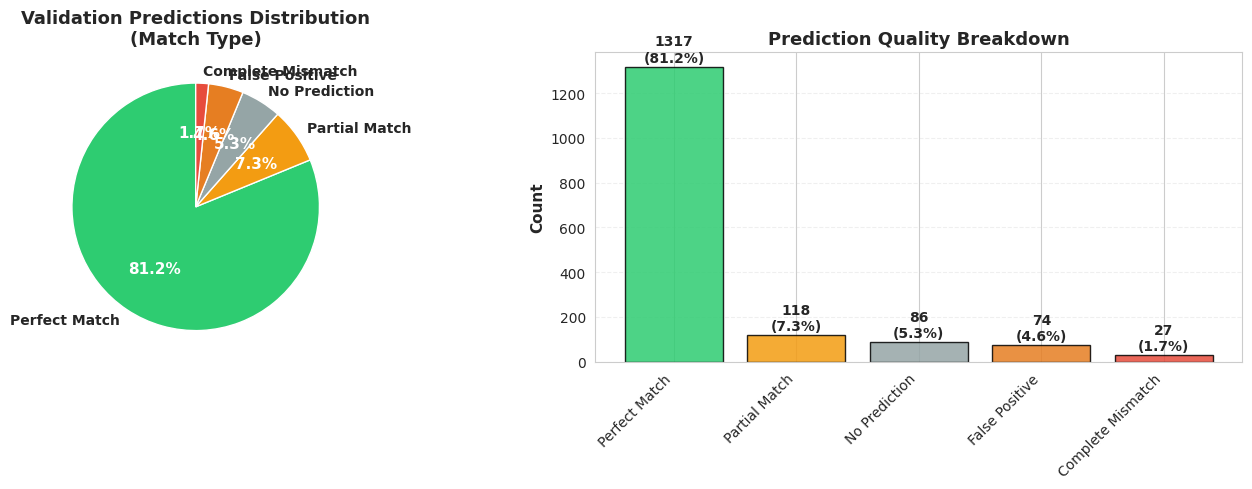


✅ VALIDATION PREDICTIONS TERSIMPAN!


In [ ]:
print("\n" + "="*80)
print("MENYIMPAN VALIDATION PREDICTIONS")
print("="*80 + "\n")

# Decode predictions dari binary ke label asli
y_true_decoded = []
y_pred_decoded = []

for i in range(len(validation_results['y_true'])):
    # True labels
    true_binary = validation_results['y_true'][i]
    true_labels = (
    mlb.inverse_transform(np.array([true_binary]))[0]
    if np.any(true_binary)
    else []
)

    # Predicted labels
    pred_binary = validation_results['y_pred'][i]
    pred_labels = (
    mlb.inverse_transform(np.array([pred_binary]))[0]
    if np.any(pred_binary)
    else []
)

    y_true_decoded.append(list(true_labels))
    y_pred_decoded.append(list(pred_labels))

# Create predictions DataFrame
validation_predictions = pd.DataFrame({
    'ulasan': validation_df['final_text'].values,
    'y_true': y_true_decoded,
    'y_pred': y_pred_decoded,
})

# Add columns for easier analysis
def extract_aspects_and_sentiments(labels):
    """Extract aspects and sentiments from label list"""
    aspects = []
    sentiments = []

    for label in labels:
        if '_' in label:
            parts = label.rsplit('_', 1)
            aspects.append(parts[0].replace('_', ' '))
            sentiments.append(parts[1].capitalize())

    return aspects, sentiments

# Process true labels
validation_predictions['true_aspects'] = validation_predictions['y_true'].apply(
    lambda x: ', '.join(extract_aspects_and_sentiments(x)[0]) if x else 'Tidak ada'
)
validation_predictions['true_sentiments'] = validation_predictions['y_true'].apply(
    lambda x: ', '.join(extract_aspects_and_sentiments(x)[1]) if x else '-'
)

# Process predicted labels
validation_predictions['pred_aspects'] = validation_predictions['y_pred'].apply(
    lambda x: ', '.join(extract_aspects_and_sentiments(x)[0]) if x else 'Tidak ada'
)
validation_predictions['pred_sentiments'] = validation_predictions['y_pred'].apply(
    lambda x: ', '.join(extract_aspects_and_sentiments(x)[1]) if x else '-'
)

# Add correctness column
validation_predictions['is_correct'] = (
    validation_predictions['y_true'].astype(str) == validation_predictions['y_pred'].astype(str)
)

# Add match type
def get_match_type(true_labels, pred_labels):
    """Determine type of match"""
    if true_labels == pred_labels:
        return 'Perfect Match'
    elif not pred_labels:
        return 'No Prediction'
    elif not true_labels:
        return 'False Positive'
    else:
        # Partial match
        true_set = set(true_labels)
        pred_set = set(pred_labels)

        if true_set == pred_set:
            return 'Perfect Match'
        elif true_set.intersection(pred_set):
            return 'Partial Match'
        else:
            return 'Complete Mismatch'

validation_predictions['match_type'] = validation_predictions.apply(
    lambda row: get_match_type(row['y_true'], row['y_pred']), axis=1
)

# Reorder columns
validation_predictions = validation_predictions[[
    'ulasan',
    'true_aspects',
    'true_sentiments',
    'pred_aspects',
    'pred_sentiments',
    'is_correct',
    'match_type',
    'y_true',
    'y_pred'
]]

# Save to CSV
validation_predictions.to_csv('/content/validation_predictions.csv', index=False)
print("✅ Validation predictions disimpan: /content/validation_predictions.csv")

# Display statistics
print("\n" + "-"*80)
print("STATISTIK PREDIKSI VALIDATION:")
print("-"*80)
print(f"Total samples        : {len(validation_predictions):,}")
print(f"Perfect Match        : {(validation_predictions['match_type'] == 'Perfect Match').sum():,} "
      f"({(validation_predictions['match_type'] == 'Perfect Match').sum() / len(validation_predictions) * 100:.2f}%)")
print(f"Partial Match        : {(validation_predictions['match_type'] == 'Partial Match').sum():,} "
      f"({(validation_predictions['match_type'] == 'Partial Match').sum() / len(validation_predictions) * 100:.2f}%)")
print(f"Complete Mismatch    : {(validation_predictions['match_type'] == 'Complete Mismatch').sum():,} "
      f"({(validation_predictions['match_type'] == 'Complete Mismatch').sum() / len(validation_predictions) * 100:.2f}%)")
print(f"No Prediction        : {(validation_predictions['match_type'] == 'No Prediction').sum():,} "
      f"({(validation_predictions['match_type'] == 'No Prediction').sum() / len(validation_predictions) * 100:.2f}%)")
print(f"False Positive       : {(validation_predictions['match_type'] == 'False Positive').sum():,} "
      f"({(validation_predictions['match_type'] == 'False Positive').sum() / len(validation_predictions) * 100:.2f}%)")

# Display sample predictions
print("\n" + "-"*80)
print("SAMPLE PREDICTIONS (5 baris pertama):")
print("-"*80)
display_cols = ['ulasan', 'true_aspects', 'pred_aspects', 'match_type']
print(validation_predictions[display_cols].head(10).to_string(index=False))

# ============================================================================
# ANALISIS ERROR (Predictions yang Salah)
# ============================================================================

print("\n" + "="*80)
print("ANALISIS ERROR PREDICTIONS")
print("="*80 + "\n")

# Filter hanya yang salah
errors = validation_predictions[validation_predictions['match_type'] != 'Perfect Match']

print(f"Total errors: {len(errors):,} / {len(validation_predictions):,} "
      f"({len(errors) / len(validation_predictions) * 100:.2f}%)")

if len(errors) > 0:
    # Save errors to separate file
    errors.to_csv('/content/validation_errors.csv', index=False)
    print("✅ Error predictions disimpan: /content/validation_errors.csv")

    # Display sample errors
    print("\n" + "-"*80)
    print("SAMPLE ERRORS (5 contoh):")
    print("-"*80)
    sample_errors = errors.head(5)
    for idx, row in sample_errors.iterrows():
        print(f"\nUlasan: {row['ulasan'][:100]}...")
        print(f"True   : {row['true_aspects']} ({row['true_sentiments']})")
        print(f"Pred   : {row['pred_aspects']} ({row['pred_sentiments']})")
        print(f"Type   : {row['match_type']}")
        print("-" * 80)
else:
    print("✅ Tidak ada error! (Perfect predictions)")

# ============================================================================
# VISUALISASI MATCH TYPE DISTRIBUTION
# ============================================================================

print("\n" + "="*80)
print("VISUALISASI MATCH TYPE DISTRIBUTION")
print("="*80 + "\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Pie Chart
ax1 = axes[0]
match_counts = validation_predictions['match_type'].value_counts()
colors = {
    'Perfect Match': '#2ecc71',
    'Partial Match': '#f39c12',
    'Complete Mismatch': '#e74c3c',
    'No Prediction': '#95a5a6',
    'False Positive': '#e67e22'
}
plot_colors = [colors.get(label, '#3498db') for label in match_counts.index]

wedges, texts, autotexts = ax1.pie(
    match_counts.values,
    labels=match_counts.index,
    autopct='%1.1f%%',
    colors=plot_colors,
    startangle=90,
    textprops={'fontsize': 10, 'fontweight': 'bold'}
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)

ax1.set_title('Validation Predictions Distribution\n(Match Type)',
              fontsize=13, fontweight='bold')

# Plot 2: Bar Chart
ax2 = axes[1]
bars = ax2.bar(range(len(match_counts)), match_counts.values,
               color=plot_colors, alpha=0.85, edgecolor='black', linewidth=1)

# Add values and percentages on bars
for i, (bar, count) in enumerate(zip(bars, match_counts.values)):
    height = bar.get_height()
    percentage = count / len(validation_predictions) * 100
    ax2.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xticks(range(len(match_counts)))
ax2.set_xticklabels(match_counts.index, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Count', fontsize=11, fontweight='bold')
ax2.set_title('Prediction Quality Breakdown', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('/content/validation_match_distribution.png', dpi=300, bbox_inches='tight')
print("✅ Grafik match distribution disimpan: /content/validation_match_distribution.png")
plt.show()

print("\n" + "="*80)
print("✅ VALIDATION PREDICTIONS TERSIMPAN!")
print("="*80)


# VISUALISASI OVERFITTING ANALYSIS


VISUALISASI OVERFITTING ANALYSIS

✅ Grafik overfitting disimpan: /content/overfitting_analysis_detailed.png


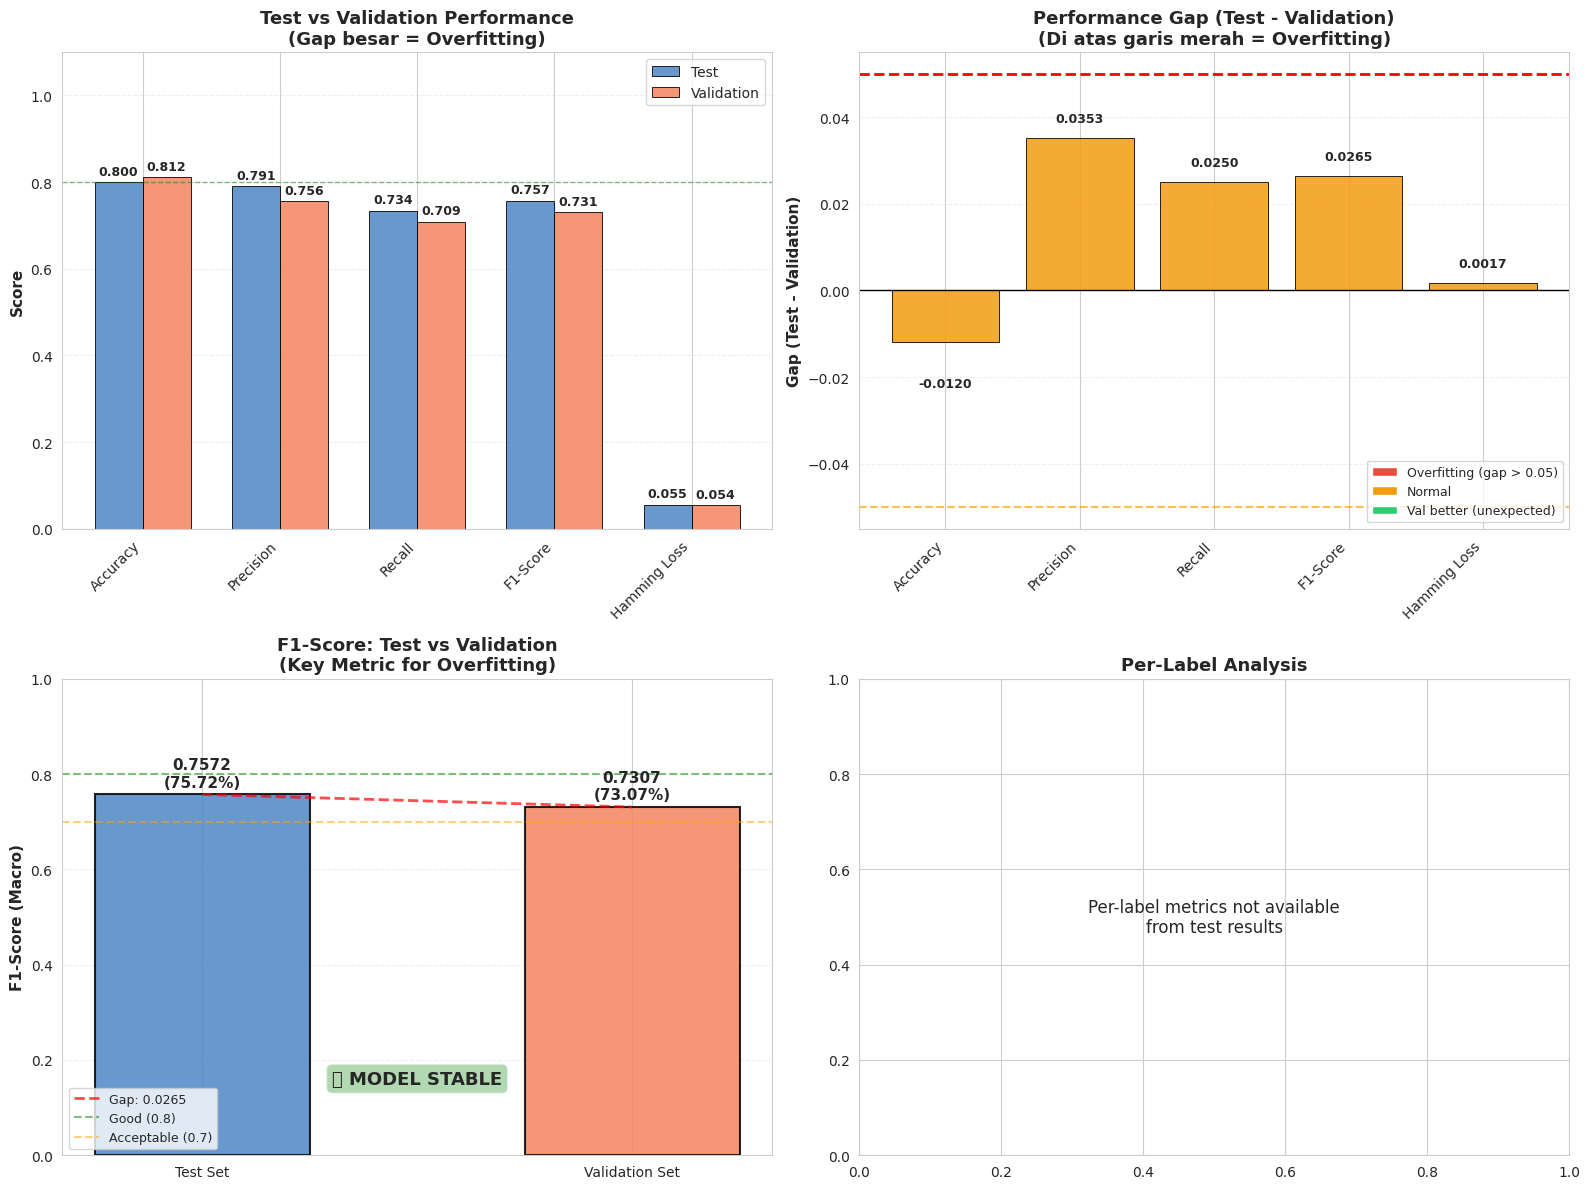


OVERFITTING ANALYSIS SUMMARY

      Metric     Test  Validation       Gap Status
    Accuracy 0.800000    0.811961 -0.011961   ✅ OK
   Precision 0.791208    0.755954  0.035254   ✅ OK
      Recall 0.734021    0.709065  0.024956   ✅ OK
    F1-Score 0.757176    0.730698  0.026478   ✅ OK
Hamming Loss 0.055308    0.053637  0.001671   ✅ OK

--------------------------------------------------------------------------------

Average Gap (first 4 metrics): 0.0247
Overall Status: ✅ GOOD GENERALIZATION - Model is stable

✅ Tabel overfitting disimpan: /content/overfitting_summary.csv

LEARNING CURVE VISUALIZATION

✅ Learning curve disimpan: /content/learning_curve_visualization.png


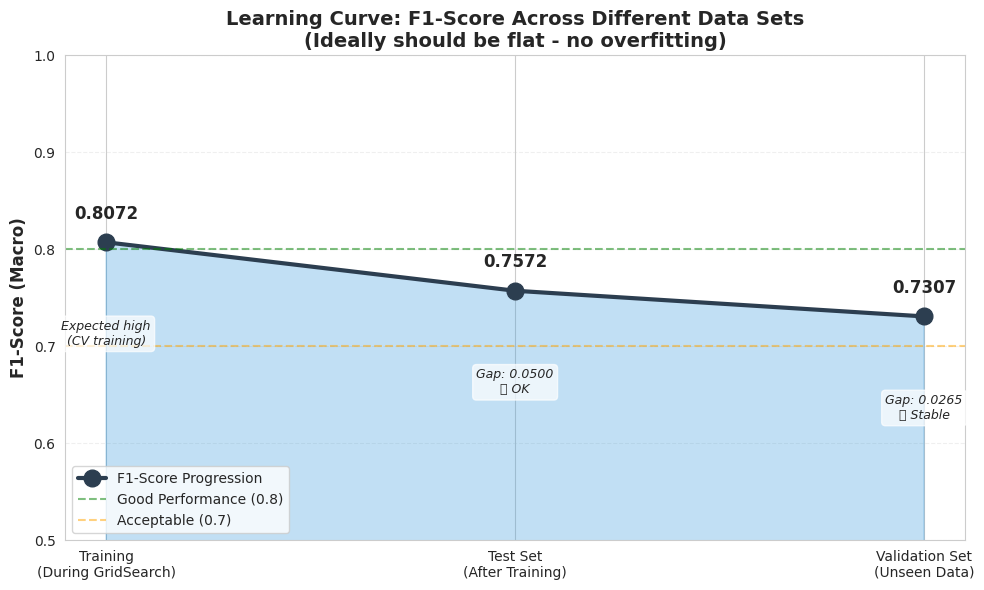


✅ VISUALISASI OVERFITTING SELESAI!


In [ ]:
print("\n" + "="*80)
print("VISUALISASI OVERFITTING ANALYSIS")
print("="*80 + "\n")

# Data untuk visualisasi
test_metrics = best_model_info['metrics']
val_metrics = validation_results['metrics']

# ============================================================================
# PLOT 1: Train vs Test vs Validation (Bar Chart)
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Jika ada train metrics di best_model_info (jika tidak, skip plot ini)
# Asumsikan kita hanya punya Test dan Validation
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Hamming Loss']
test_values = [
    test_metrics['accuracy'],
    test_metrics['precision_macro'],
    test_metrics['recall_macro'],
    test_metrics['f1_macro'],
    test_metrics['hamming_loss']
]
val_values = [
    val_metrics['accuracy'],
    val_metrics['precision_macro'],
    val_metrics['recall_macro'],
    val_metrics['f1_macro'],
    val_metrics['hamming_loss']
]

# Plot 1: Test vs Validation Comparison
ax1 = axes[0, 0]
x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax1.bar(x - width/2, test_values, width, label='Test',
                alpha=0.85, color='#4f86c6', edgecolor='black', linewidth=0.7)
bars2 = ax1.bar(x + width/2, val_values, width, label='Validation',
                alpha=0.85, color='#f4845f', edgecolor='black', linewidth=0.7)

# Add values on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_title('Test vs Validation Performance\n(Gap besar = Overfitting)',
              fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names, rotation=45, ha='right', fontsize=10)
ax1.set_ylabel('Score', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 1.1)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.axhline(y=0.8, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Target 0.8')

# Highlight overfitting metrics (gap > 0.05)
for i, (test_val, val_val) in enumerate(zip(test_values, val_values)):
    gap = abs(test_val - val_val)
    if gap > 0.05:
        ax1.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='red')

# ============================================================================
# PLOT 2: Gap Analysis (Difference between Test and Validation)
# ============================================================================

ax2 = axes[0, 1]

gaps = [test_val - val_val for test_val, val_val in zip(test_values, val_values)]
colors = ['#e74c3c' if g > 0.05 else '#2ecc71' if g < -0.02 else '#f39c12'
          for g in gaps]

bars = ax2.bar(x, gaps, color=colors, alpha=0.85, edgecolor='black', linewidth=0.7)

# Add values
for i, (bar, gap) in enumerate(zip(bars, gaps)):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2.,
            height + 0.003 if height >= 0 else height - 0.008,
            f'{height:.4f}', ha='center', va='bottom' if height >= 0 else 'top',
            fontsize=9, fontweight='bold')

ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=2,
            label='Threshold overfitting (0.05)')
ax2.axhline(y=0, color='black', linewidth=1)
ax2.axhline(y=-0.05, color='orange', linestyle='--', linewidth=1.5, alpha=0.7,
            label='Validation better zone')

ax2.set_title('Performance Gap (Test - Validation)\n(Di atas garis merah = Overfitting)',
              fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names, rotation=45, ha='right', fontsize=10)
ax2.set_ylabel('Gap (Test - Validation)', fontsize=11, fontweight='bold')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Overfitting (gap > 0.05)'),
    Patch(facecolor='#f39c12', label='Normal'),
    Patch(facecolor='#2ecc71', label='Val better (unexpected)')
]
ax2.legend(handles=legend_elements, loc='lower right', fontsize=9)

# ============================================================================
# PLOT 3: F1-Score Trend (Test vs Validation)
# ============================================================================

ax3 = axes[1, 0]

categories = ['Test Set', 'Validation Set']
f1_scores = [test_metrics['f1_macro'], val_metrics['f1_macro']]
colors_f1 = ['#4f86c6', '#f4845f']

bars = ax3.bar(categories, f1_scores, color=colors_f1, alpha=0.85,
               edgecolor='black', linewidth=1.5, width=0.5)

# Add values and percentage
for i, (bar, f1) in enumerate(zip(bars, f1_scores)):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{f1:.4f}\n({f1*100:.2f}%)', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# Add gap indicator
gap_f1 = test_metrics['f1_macro'] - val_metrics['f1_macro']
ax3.plot([0, 1], [test_metrics['f1_macro'], val_metrics['f1_macro']],
         'r--', linewidth=2, alpha=0.7, label=f'Gap: {gap_f1:.4f}')

# Reference lines
ax3.axhline(y=0.8, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='Good (0.8)')
ax3.axhline(y=0.7, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='Acceptable (0.7)')

ax3.set_title('F1-Score: Test vs Validation\n(Key Metric for Overfitting)',
              fontsize=13, fontweight='bold')
ax3.set_ylabel('F1-Score (Macro)', fontsize=11, fontweight='bold')
ax3.set_ylim(0, 1)
ax3.legend(loc='lower left', fontsize=9)
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Status text
if gap_f1 > 0.10:
    status_text = "❌ OVERFITTING DETECTED"
    status_color = 'red'
elif gap_f1 > 0.05:
    status_text = "⚠️ MINOR OVERFITTING"
    status_color = 'orange'
else:
    status_text = "✅ MODEL STABLE"
    status_color = 'green'

ax3.text(0.5, 0.15, status_text, transform=ax3.transAxes,
         fontsize=13, fontweight='bold', ha='center',
         bbox=dict(boxstyle='round', facecolor=status_color, alpha=0.3))

# ============================================================================
# PLOT 4: Per-Label Overfitting Analysis
# ============================================================================

ax4 = axes[1, 1]

# Get per-label F1 scores
test_per_label = best_model_info.get('per_label_metrics', [])
val_per_label = validation_results['per_label_metrics']

if test_per_label and val_per_label:
    labels = [item['label'] for item in val_per_label]

    # Match labels
    test_f1_per_label = []
    val_f1_per_label = []

    for val_item in val_per_label:
        val_label = val_item['label']
        val_f1_per_label.append(val_item['f1_score'])

        # Find matching test label
        test_f1 = next((item['f1_score'] for item in test_per_label
                       if item['label'] == val_label), 0)
        test_f1_per_label.append(test_f1)

    x_labels = np.arange(len(labels))
    width = 0.35

    bars1 = ax4.bar(x_labels - width/2, test_f1_per_label, width,
                    label='Test', alpha=0.85, color='#4f86c6', edgecolor='black', linewidth=0.7)
    bars2 = ax4.bar(x_labels + width/2, val_f1_per_label, width,
                    label='Validation', alpha=0.85, color='#f4845f', edgecolor='black', linewidth=0.7)

    # Add values
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=8)

    ax4.set_title('Per-Label F1-Score: Test vs Validation',
                  fontsize=13, fontweight='bold')
    ax4.set_xticks(x_labels)
    ax4.set_xticklabels([lbl.replace('_', '\n') for lbl in labels],
                        rotation=45, ha='right', fontsize=8)
    ax4.set_ylabel('F1-Score', fontsize=11, fontweight='bold')
    ax4.set_ylim(0, 1)
    ax4.legend(loc='upper right', fontsize=9)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    ax4.axhline(y=0.7, color='orange', linestyle='--', linewidth=1, alpha=0.5)

    # Highlight problematic labels
    for i, (test_f1, val_f1) in enumerate(zip(test_f1_per_label, val_f1_per_label)):
        gap = test_f1 - val_f1
        if gap > 0.10:
            ax4.axvspan(i - 0.5, i + 0.5, alpha=0.1, color='red')
else:
    ax4.text(0.5, 0.5, 'Per-label metrics not available\nfrom test results',
             ha='center', va='center', fontsize=12, transform=ax4.transAxes)
    ax4.set_title('Per-Label Analysis', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/overfitting_analysis_detailed.png', dpi=300, bbox_inches='tight')
print("✅ Grafik overfitting disimpan: /content/overfitting_analysis_detailed.png")
plt.show()

# ============================================================================
# SUMMARY TABLE
# ============================================================================

print("\n" + "="*80)
print("OVERFITTING ANALYSIS SUMMARY")
print("="*80 + "\n")

summary_table = pd.DataFrame({
    'Metric': metrics_names,
    'Test': test_values,
    'Validation': val_values,
    'Gap': gaps,
    'Status': ['⚠️ Overfit' if abs(g) > 0.05 else '✅ OK' for g in gaps]
})

print(summary_table.to_string(index=False))
print("\n" + "-"*80)

# Overall assessment
avg_gap = np.mean([abs(g) for g in gaps[:4]])  # Exclude hamming loss
print(f"\nAverage Gap (first 4 metrics): {avg_gap:.4f}")

if avg_gap > 0.10:
    overall_status = "❌ SEVERE OVERFITTING - Model needs regularization"
elif avg_gap > 0.05:
    overall_status = "⚠️ MODERATE OVERFITTING - Acceptable but could improve"
else:
    overall_status = "✅ GOOD GENERALIZATION - Model is stable"

print(f"Overall Status: {overall_status}")

# Save summary
summary_table.to_csv('/content/overfitting_summary.csv', index=False)
print("\n✅ Tabel overfitting disimpan: /content/overfitting_summary.csv")

# ============================================================================
# ADDITIONAL: Learning Curve Style Visualization
# ============================================================================

print("\n" + "="*80)
print("LEARNING CURVE VISUALIZATION")
print("="*80 + "\n")

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Simulate learning curve (Test -> Validation as progression)
phases = ['Training\n(During GridSearch)', 'Test Set\n(After Training)', 'Validation Set\n(Unseen Data)']
# Note: We don't have actual training metrics, so we'll estimate
# Typically training F1 would be higher than test F1
estimated_train_f1 = test_metrics['f1_macro'] + 0.05  # Estimate
f1_progression = [estimated_train_f1, test_metrics['f1_macro'], val_metrics['f1_macro']]

# Plot
line = ax.plot(phases, f1_progression, marker='o', linewidth=3, markersize=12,
               color='#2c3e50', label='F1-Score Progression')

# Fill area
ax.fill_between(range(len(phases)), f1_progression, alpha=0.3, color='#3498db')

# Add values
for i, (phase, f1) in enumerate(zip(phases, f1_progression)):
    ax.text(i, f1 + 0.02, f'{f1:.4f}', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

    # Add status
    if i == 0:
        status = "Expected high\n(CV training)"
    elif i == 1:
        gap_train_test = f1_progression[0] - f1_progression[1]
        status = f"Gap: {gap_train_test:.4f}\n{'⚠️ Overfit' if gap_train_test > 0.10 else '✅ OK'}"
    else:
        gap_test_val = f1_progression[1] - f1_progression[2]
        status = f"Gap: {gap_test_val:.4f}\n{'⚠️ Drop' if gap_test_val > 0.05 else '✅ Stable'}"

    ax.text(i, f1 - 0.08, status, ha='center', va='top',
            fontsize=9, style='italic',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# Reference lines
ax.axhline(y=0.8, color='green', linestyle='--', linewidth=1.5, alpha=0.5, label='Good Performance (0.8)')
ax.axhline(y=0.7, color='orange', linestyle='--', linewidth=1.5, alpha=0.5, label='Acceptable (0.7)')

ax.set_title('Learning Curve: F1-Score Across Different Data Sets\n(Ideally should be flat - no overfitting)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('F1-Score (Macro)', fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1)
ax.legend(loc='lower left', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Shaded regions
if f1_progression[0] - f1_progression[2] > 0.15:
    ax.axhspan(0.5, 1, alpha=0.05, color='red', label='Overfitting Zone')

plt.tight_layout()
plt.savefig('/content/learning_curve_visualization.png', dpi=300, bbox_inches='tight')
print("✅ Learning curve disimpan: /content/learning_curve_visualization.png")
plt.show()

print("\n" + "="*80)
print("✅ VISUALISASI OVERFITTING SELESAI!")
print("="*80)